# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

 **Цель исследования:**\
с помощью исследовательского анализа данных провести исследование и установить параметры, влияющие на цену квартир в Санкт-Петербурге и соседних населённых пунктах. Это позволит построить автоматизированную систему, которая будет отслеживать аномалии и мошенническую деятельность. 


 **Описание данных:**\
данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных.



 **План исследования:**

1) открыть файл с данными и изучить общую информацию;\
2) выполнить предобработку данных (обработать пропуски, проверить типы данных в столбцах, обработать дубликаты);\
3) добавить новые столбцы для дальнейшего анализа данных;\
4) провести исследовательский анализ (изучить распределение данных с помощью гистограмм, определить факторы, которые больше всего влияют на общую стоимость объекта, посчитать среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений, вычислить среднюю стоимость квартир в Санкт-Петербурге на разном удалении от центра);\
5) общий вывод.


###  Откройте файл с данными и изучите общую информацию

In [2]:
import warnings
warnings.filterwarnings('ignore')

#### Загрузка датафрейма

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt

In [4]:
try:
    data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')



In [5]:
display(data.head()) # исправила вместо print

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


#### Основная информация

In [6]:
# смотрим основную информацию
data.info()

# сохраняем количество строк в датафрейме в переменную, чтобы потом подсчитать процент удаленных данных
print()
data_len_1 = len(data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

#### Гистограммы

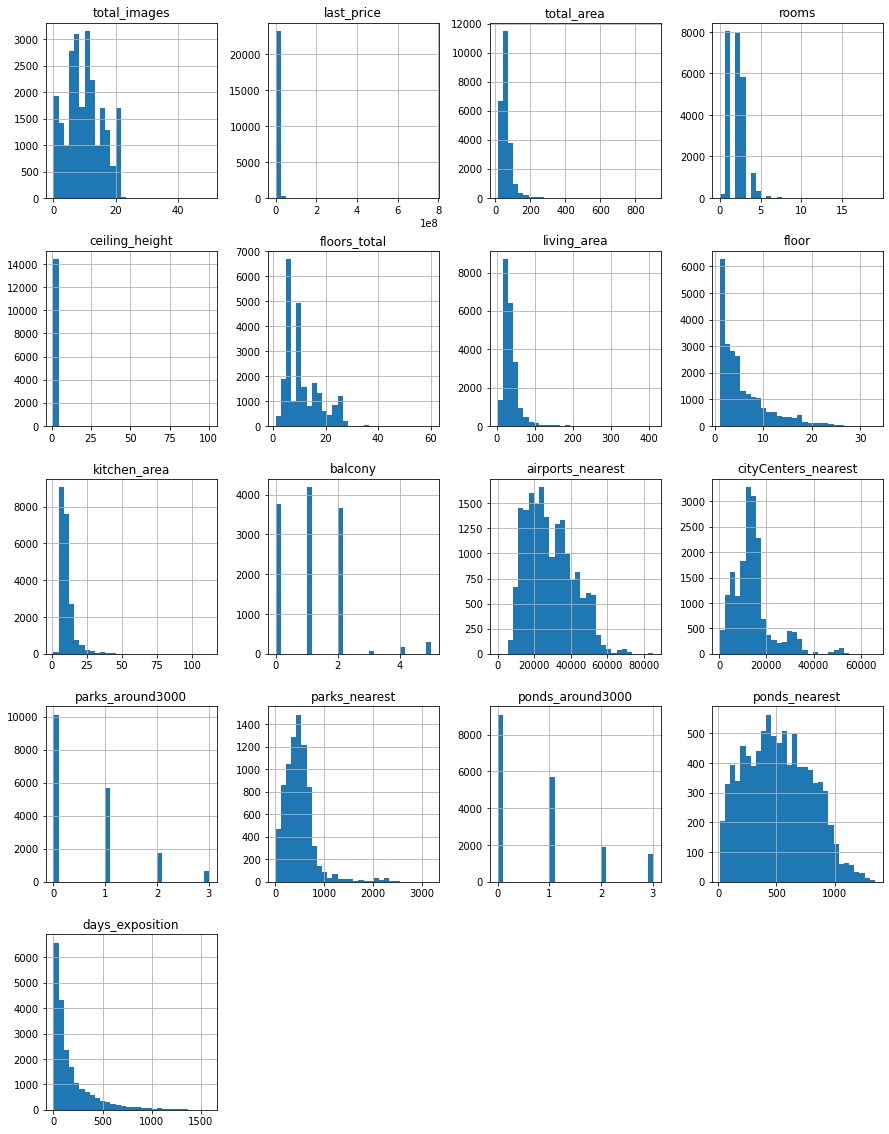

In [7]:
# строим гистограммы для всех числовых столбцов таблицы
data.hist(bins=30, figsize=(15, 20));

По гистограммам можно увидеть следующее:
1) количество прудов и парков в радиусе 3000 метров;\
2) непонятный единственный пик на гистограмме по столбцу last_price - нужно будет отдельно посмотреть этот параметр;\
3) примерное распределение количества комнат, этажей в зданиях и балконов.

### Выполните предобработку данных

#### Переименование столбцов по правилам

In [8]:
data = data.rename(columns={'cityCenters_nearest':'city_centers_nearest'})

#### Обработка пропусков

In [9]:
# выводим количество пропущенных значений для каждого столбца
data.isna().sum() 

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

 ***Вывод:***\
 Пропуски обнаружены в столбцах: с высотой потолков, с количеством этажей в доме, с жилой площадью, является ли апартаментами,
с площадью кухни, с числом балконов, с названием населенного пункта, с расстоянием до ближайшего аэропорта, с  расстоянием до центра города, с числом парков в радиусе 3 км, с расстоянием до ближайшего парка, с числом водоёмов в радиусе 3 км, с расстоянием до ближайшего водоёма, сколько дней было размещено объявление
 
 Пропуски могут быть связаны с человеческим фактором (забыл заполнить или пропуск вместо 0) или с техническим (сбой в системе, потеря или отсутствие данных в системе).
 
 Пропуски в следующих столбцах связаны с техническим фактором: 
 - расстояние до центра;
 - аэропорта;
 - до ближайшего парка;
 - до ближайшего пруда.
 
 Пропуски в следующих столбцах связаны с человеческим фактором: 
 - высота потолков;
 - количество этажей в доме ;
 - жилая площадь;
 - апартаменты;
 - площадь кухни;
 - число балконов.
 
 Под вопросом название пункта - скорее всего из-за технического фактора.


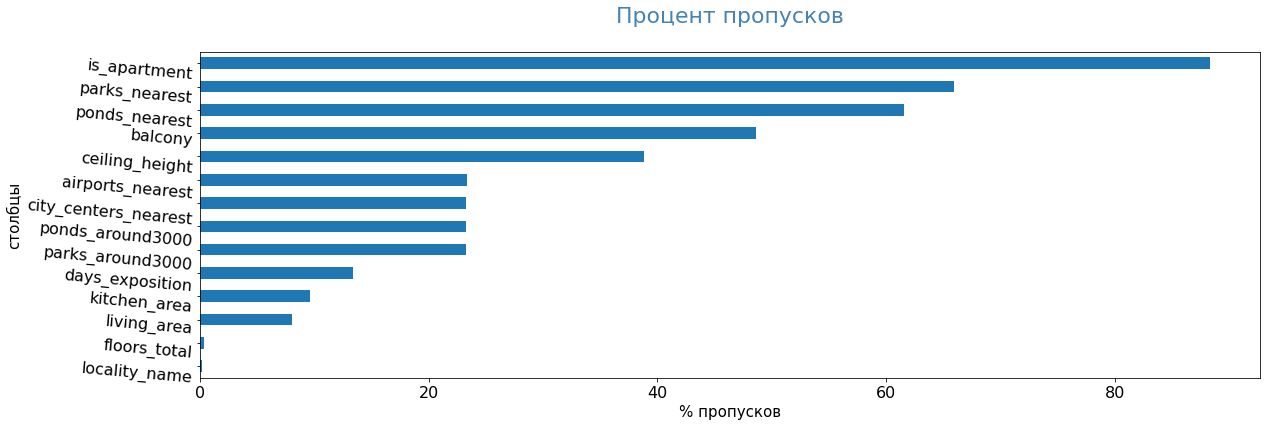

In [12]:
def pass_value_barh(df):
    try:
        (
            (df.isna().mean()*100)
            .to_frame()
            .rename(columns = {0:'space'})
            .query('space > 0')
            .sort_values(by = 'space', ascending = True)
            .plot(kind = 'barh', figsize = (19,6), rot = -5, legend = False, fontsize = 16)
            .set_title('Процент пропусков' + "\n", fontsize = 22, color = 'SteelBlue')   
       )  
        plt.xlabel("% пропусков", fontsize = 15)
        plt.ylabel("столбцы", fontsize = 15)
           
    except:
        print('пропусков не осталось :) или произошла ошибка в первой части функции ')

pass_value_barh(data)

In [13]:
# проверяем перечень уникальных значений столбца is_apartment
data['is_apartment'].unique()

array([nan, False, True], dtype=object)

In [14]:
# заполняем пропуски False в столбце is_apartment, так как пропуск скорее всего означает, что это не аппартаменты
data['is_apartment'] = data['is_apartment'].fillna(False)

# проверяем
data['is_apartment'].unique() 

array([False,  True])

In [15]:
# проверяем перечень уникальных значений столбца balcony
data['balcony'].unique()

array([nan,  2.,  0.,  1.,  5.,  4.,  3.])

In [16]:
# заполняем пропуски 0 в столбце balcony, так как если продавец
# не указал их количество, то их скорее всего и нет
data['balcony'] = data['balcony'].fillna(0)

# проверяем
data['balcony'].unique()

array([0., 2., 1., 5., 4., 3.])

In [17]:
# удаляем строки с пропусками в столбцах floors_total и locality_name,
# так как их число очень мало и на общую картину 
# сильно не влияет
data = data.dropna(subset=['floors_total', 'locality_name'])

In [18]:
# заполним пропуски в столбце living_area по расчетам через средний коэффициент
# отношения жилой площади к общей площади квартиры

# фильтруем датафрейм, чтобы не было пропусков в столбцах kitchen_area и total_area
data_not_nan = data.query('not living_area.isnull() and not total_area.isnull()')

# считаем средний коэффициент отношения жилой площади к общей площади квартиры
avg_coeff_living_area = (data_not_nan['living_area'] / (data_not_nan['total_area'])).mean()

# фильтруем - делаем срез строк в отдельный датафрейм, где есть пропуски
# в столбце living_area
nan_living_area = data.query('living_area.isna()')

# заполняем пропуски в новом датафрейме
nan_living_area['living_area'] = nan_living_area['total_area'] * avg_coeff_living_area

# заполняем пропуски в data
data.loc[nan_living_area.index, 'living_area'] = nan_living_area['living_area']
display(data.head())

# или второй вариант, когда не будет замечания, которое 
# я отключила по подсказке преподавателя в самой первой ячейке:

#avg_coef_living_area = (data['living_area'] / data['total_area']).mean()

#nan_living_area = data[data['living_area'].isna()]

#nan_living_area.loc[:, 'living_area'] = nan_living_area['total_area'] * avg_coef_living_area

#data = data.fillna(nan_living_area)


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.000000,8,False,...,25.0,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.600000,1,False,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.300000,4,False,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,89.825011,9,False,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.000000,13,False,...,41.0,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [19]:
# заполним пропуски в столбце kitchen_area по расчетам через средний коэффициент
# отношения площади кухни к общей площади квартиры

# фильтруем датафрейм, чтобы не было пропусков в столбцах kitchen_area и total_area
data_not_nan = data.query('not kitchen_area.isnull() and not total_area.isnull()')


# считаем средний коэффициент отношения площади кухни к общей площади квартиры по отфильтрованным данным
avg_coeff_kitchen_area = (data_not_nan['kitchen_area'] / (data_not_nan['total_area'])).mean()
# исправила, учтя, что 0.1 доля общей площади отводится на другие части квартиры

# фильтруем - делаем срез строк в отдельный датафрейм, где есть пропуски в столбце kitchen_area
nan_kitchen_area = data.query('kitchen_area.isna()')

# заполняем пропуски в новом датафрейме
nan_kitchen_area['kitchen_area'] = nan_kitchen_area['total_area'] * avg_coeff_kitchen_area

# заполняем пропуски в data
data.loc[nan_kitchen_area.index, 'kitchen_area'] = nan_kitchen_area['kitchen_area']
display(data.head())

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.000000,8,False,...,25.000000,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.600000,1,False,...,11.000000,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.300000,4,False,...,8.300000,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,89.825011,9,False,...,29.786996,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.000000,13,False,...,41.000000,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [20]:
# проверяем по формуле строки, в которых жилая площадь и площадь кухни занимают 90% 
# и более от общей площади по столбцу living_area после заполнения пропусков
alpha = nan_living_area.query('total_area*0.9 <= (living_area + kitchen_area)')
print(len(alpha))
print()

# проверяем по формуле строки, в которых жилая площадь и площадь кухни занимают 90% 
# и более от общей площади по столбцу kitchen_area после заполнения пропусков
betta = nan_kitchen_area.query('total_area*0.9 <= (living_area + kitchen_area)')
print(len(betta))

33

179


*Полученные значения по формуле на мой взгляд не могут судить о том, правильным ли способом мы заполняем пропуски в столбцах с жилой площадью и площадью кухни, так как их сумма может быть как меньше 0.9 части общей площади, так и больше. \
Вследствие этого проверяю заполненные пропуски ниже через взятые из шага 4.1 пороговые значения площадей, что нелогично.\
Другого способа проверить заполненные данные я найти не смогла.*

##### check area

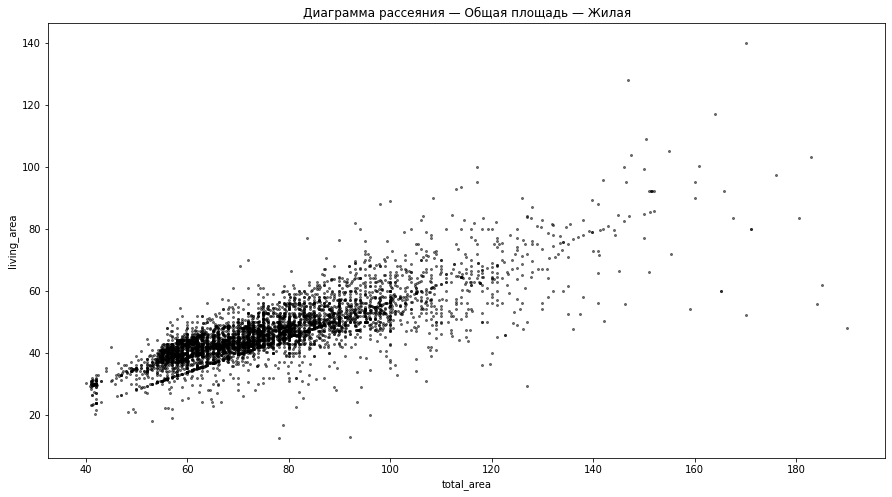

In [21]:
# check
data[data['rooms'] == 3].query('total_area < 201 and last_price < 25_000_000').plot(kind='scatter',
        y='living_area' , x='total_area', alpha=0.5, subplots=True, figsize=(15,8), c = 'black', s = 4)
plt.title('Диаграмма рассеяния — Общая площадь — Жилая');

In [22]:
#выводим строки с проверкой слишком маленьких и слишком больших жилых площадей 
small_living = nan_living_area.query('living_area <= 2')
big_living = nan_living_area.query('living_area >= 160')


print(small_living['living_area'])
print()
print(big_living['living_area'])


Series([], Name: living_area, dtype: float64)

581      206.202069
1388     225.409933
2243     171.740901
3117     356.475357
3676     249.690933
5873     225.974870
5893     282.468587
6183     205.128688
9826     279.135458
10181    166.656467
10684    206.032588
15016    282.468587
19392    209.591692
22131    238.516475
Name: living_area, dtype: float64


*Слишком маленьких результатов после расчета жилой площади через коэффициент нет, но есть 14 слишком больших значений, то есть, возможно, алгоритм создает очень маленький процент выбивающихся значений, которые практически не влияют на распределение данных.*

In [23]:
#выводим строки с проверкой слишком маленьких и слишком больших площадей кухни
small_kitchens = nan_kitchen_area.query('kitchen_area <= 1.3')
big_kitchens = nan_kitchen_area.query('kitchen_area >= 50')


print(small_kitchens['kitchen_area'])
print()
print(big_kitchens['kitchen_area'])


Series([], Name: kitchen_area, dtype: float64)

155      59.386653
581      68.378953
1388     74.748500
2243     56.951238
5631     52.455088
5873     74.935839
7274     52.455088
7674     71.189047
9826     92.564496
10181    55.265182
10684    68.322752
11436    59.255515
12971    74.935839
15016    93.669799
19392    69.502991
22131    79.094779
Name: kitchen_area, dtype: float64


*Слишком маленьких результатов после расчета площади кухни через коэффициент нет, но есть 16 слишком больших значений, то есть, возможно, алгоритм создает очень маленький процент выбивающихся значений, которые практически не влияют на распределение данных*

In [24]:
# проверяем, что избавились от тех пропусков, от которых можно было избавиться
print(data.isna().sum())

print()
# проверяем, что процент удаленных данных не повлияет на объективность результатов
data_len_2 = len(data)
print((data_len_2/data_len_1)*100)

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9084
floors_total                0
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest         5524
city_centers_nearest     5501
parks_around3000         5500
parks_nearest           15535
ponds_around3000         5500
ponds_nearest           14529
days_exposition          3171
dtype: int64

99.4345752985358


***Вывод:***\
Расстояния до аэропортов, центров города, ближайших парка и пруда не заполняем - так как выгрузка была автоматическая 
без участия продавца.
Также мы не можем заполнить пропуски в столбцах с количеством дней, сколько было размещено объявление, высотой потолков, парками и прудами в радиусе 3 км, так как нет привязки к другим факторам, от которых можно было бы отталкиваться при расчетах, например, высоту потолков можно было бы посчитать в привязке к году постройки здания.

Процент оставшихся после удаления пропусков данных 99.4, следовательно, мы удалили лишь 0.6% данных, что не повлияет на дальнейший анализ.

#### Типы данных

In [25]:
# смотрим типы данных в столбцах
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23565 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23565 non-null  int64  
 1   last_price            23565 non-null  float64
 2   total_area            23565 non-null  float64
 3   first_day_exposition  23565 non-null  object 
 4   rooms                 23565 non-null  int64  
 5   ceiling_height        14481 non-null  float64
 6   floors_total          23565 non-null  float64
 7   living_area           23565 non-null  float64
 8   floor                 23565 non-null  int64  
 9   is_apartment          23565 non-null  bool   
 10  studio                23565 non-null  bool   
 11  open_plan             23565 non-null  bool   
 12  kitchen_area          23565 non-null  float64
 13  balcony               23565 non-null  float64
 14  locality_name         23565 non-null  object 
 15  airports_nearest   

In [26]:
# меняем тип данных в столбцах floors_total и balcony 
data['floors_total'] = data['floors_total'].astype('int64')
data['balcony'] = data['balcony'].astype('int64')

# меняем тип данных в столбце first_day_exposition на datetime64
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

# проверяем
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23565 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23565 non-null  int64         
 1   last_price            23565 non-null  float64       
 2   total_area            23565 non-null  float64       
 3   first_day_exposition  23565 non-null  datetime64[ns]
 4   rooms                 23565 non-null  int64         
 5   ceiling_height        14481 non-null  float64       
 6   floors_total          23565 non-null  int64         
 7   living_area           23565 non-null  float64       
 8   floor                 23565 non-null  int64         
 9   is_apartment          23565 non-null  bool          
 10  studio                23565 non-null  bool          
 11  open_plan             23565 non-null  bool          
 12  kitchen_area          23565 non-null  float64       
 13  balcony         

***Вывод:***\
В столбцах parks_around3000 и ponds_around3000 изменить тип данных невозможно, так как они содержат в себе значения NaN.\
Тип данных был изменен в столбцах floors_total и balcony на на int64 (целочисленный), так как не может быть 1.5 балкона или 1.5 этажа, и в столбце first_day_exposition на на datetime64 - для работы с датами и временем.


#### Обработка дубликатов

In [27]:
# проверяем на наличие явных дубликатов
print(data.duplicated().sum())

0


In [28]:
# проверяем на наличие неявных дубликатов
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

In [29]:
# обрабатываем неявные дубликаты
data['locality_name'] = (
    data['locality_name']
    .str.replace('ё', 'е')
    .replace(['городской поселок', 'поселок городского типа', 'поселок станции',\
              'поселок при железнодорожной станции', 'коттеджный поселок'], 'поселок', regex=True)
    .replace(['садовое товарищество', 'садоводческое некоммерческое товарищество'], 'снт', regex=True)
) 

data['locality_name'].unique()

array(['Санкт-Петербург', 'поселок Шушары', 'поселок Янино-1',
       'поселок Парголово', 'поселок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок Красный Бор', 'Гатчина', 'деревня Федоровское', 'Выборг',
       'Кронштадт', 'Кировск', 'деревня Новое Девяткино',
       'поселок Металлострой', 'поселок Лебяжье', 'поселок Сиверский',
       'поселок Молодцово', 'поселок Кузьмоловский', 'снт Новая Ропша',
       'Павловск', 'деревня Пикколово', 'Всеволожск', 'Волхов',
       'Кингисепп', 'Приозерск', 'Сестрорецк', 'деревня Куттузи',
       'поселок Аннино', 'поселок Ефимовский', 'поселок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'поселок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', 'поселок Новый Свет', 'Сланцы',
       'село Путилово', 'Ивангород', 'Мурино', 'Шлиссельбург',
       'Никольское', 'Зеленогорск', 'Сосновый Бор', 

***Вывод:***\
Явных дубликатов не было обнаружено, а среди неявных приняла решение сделать все поселки городские, коттеджные и т.д. просто поселками для избавления от дубликатов, так же поступила с садовыми товариществами и садоводческими некоммерческими товариществами - они все стали "СНТ"

In [30]:
# проверяем еще раз на наличие явных дубликатов после обработки неявных
print(data.duplicated().sum())

0


#### check name

In [31]:
# check
data.locality_name.nunique()

318

### Добавьте в таблицу новые столбцы

#### Столбец со стоимостью одного квадратного метра 

In [32]:
# считаем цену одного квадратного метра и добавляем в новый столбец
data['price_one_sqr_meter'] = (data['last_price'] / data['total_area']).round(2)
display(data.head())

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_one_sqr_meter
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.000000,8,False,...,0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,120370.37
1,7,3350000.0,40.4,2018-12-04,1,NaN,11,18.600000,1,False,...,2,поселок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,82920.79
2,10,5196000.0,56.0,2015-08-20,2,NaN,5,34.300000,4,False,...,0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,92785.71
3,0,64900000.0,159.0,2015-07-24,3,NaN,14,89.825011,9,False,...,0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,408176.10
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.000000,13,False,...,0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,100000.00


#### Столбец с днем недели публикации объявления

In [33]:
# создаем столбец с днем недели публикации объявления 
data['exposition_day'] = data['first_day_exposition'].dt.weekday

# создаем функцию для присваивания названия дням недели
def weekday_name(row):
    if row == 0:
        return 'Понедельник'
    elif  row == 1:
        return 'Вторник'
    elif  row == 2:
        return 'Среда'
    elif  row == 3:
        return 'Четверг'
    elif  row == 4:
        return 'Пятница'
    elif  row == 5:
        return 'Суббота'
    elif  row == 6:
        return 'Воскресенье'

# создаем новый столбец с названиями дней недели публикации объявления
# (чтобы было удобнее потом ориентироваться в результатах)
data['name_exposition_day'] = data['exposition_day'].apply(weekday_name)        
display(data.head())
print(data['name_exposition_day'].value_counts())

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_one_sqr_meter,exposition_day,name_exposition_day
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.000000,8,False,...,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,120370.37,3,Четверг
1,7,3350000.0,40.4,2018-12-04,1,NaN,11,18.600000,1,False,...,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,82920.79,1,Вторник
2,10,5196000.0,56.0,2015-08-20,2,NaN,5,34.300000,4,False,...,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,92785.71,3,Четверг
3,0,64900000.0,159.0,2015-07-24,3,NaN,14,89.825011,9,False,...,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,408176.10,4,Пятница
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.000000,13,False,...,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,100000.00,1,Вторник


Четверг        4276
Вторник        4163
Пятница        3980
Среда          3948
Понедельник    3596
Суббота        1919
Воскресенье    1683
Name: name_exposition_day, dtype: int64


#### Столбец с месяцем публикации объявления

In [34]:
# создаем столбец с месяцем публикации объявления
data['exposition_month'] = data['first_day_exposition'].dt.month
print(data['exposition_month'].value_counts())

2     2636
3     2575
11    2360
4     2356
10    2108
9     1972
6     1747
8     1739
7     1686
12    1638
1     1487
5     1261
Name: exposition_month, dtype: int64


In [35]:
# исправила
display(data.head())

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_one_sqr_meter,exposition_day,name_exposition_day,exposition_month
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.000000,8,False,...,16028.0,1.0,482.0,2.0,755.0,NaN,120370.37,3,Четверг,3
1,7,3350000.0,40.4,2018-12-04,1,NaN,11,18.600000,1,False,...,18603.0,0.0,NaN,0.0,NaN,81.0,82920.79,1,Вторник,12
2,10,5196000.0,56.0,2015-08-20,2,NaN,5,34.300000,4,False,...,13933.0,1.0,90.0,2.0,574.0,558.0,92785.71,3,Четверг,8
3,0,64900000.0,159.0,2015-07-24,3,NaN,14,89.825011,9,False,...,6800.0,2.0,84.0,3.0,234.0,424.0,408176.10,4,Пятница,7
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.000000,13,False,...,8098.0,2.0,112.0,1.0,48.0,121.0,100000.00,1,Вторник,6


#### Столбец с годом публикации объявления

In [36]:
# создаем столбец с годом публикации объявления
data['exposition_year'] = data['first_day_exposition'].dt.year
display(data.head())
print(data['exposition_year'].value_counts())

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_one_sqr_meter,exposition_day,name_exposition_day,exposition_month,exposition_year
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.000000,8,False,...,1.0,482.0,2.0,755.0,NaN,120370.37,3,Четверг,3,2019
1,7,3350000.0,40.4,2018-12-04,1,NaN,11,18.600000,1,False,...,0.0,NaN,0.0,NaN,81.0,82920.79,1,Вторник,12,2018
2,10,5196000.0,56.0,2015-08-20,2,NaN,5,34.300000,4,False,...,1.0,90.0,2.0,574.0,558.0,92785.71,3,Четверг,8,2015
3,0,64900000.0,159.0,2015-07-24,3,NaN,14,89.825011,9,False,...,2.0,84.0,3.0,234.0,424.0,408176.10,4,Пятница,7,2015
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.000000,13,False,...,2.0,112.0,1.0,48.0,121.0,100000.00,1,Вторник,6,2018


2018    8486
2017    8161
2019    2871
2016    2745
2015    1166
2014     136
Name: exposition_year, dtype: int64


#### Столбец с типом этажа

In [37]:
# создаем функцию и присваиваем категории этажам
def floor_type(row):
    floors_total = row['floors_total']
    floor = row['floor']
    if floor == 1:
        return 'первый'
    elif floor == 0:
        return 'цокольный'
    elif floor < 0:
        return 'неизвестный'
    elif floor == floors_total:
        return 'последний'
    else:
        return 'другой'

# создаем столбец с типом этажа с помощью функции
data['floor_type'] = data.apply(floor_type, axis=1)
display(data.head())
print(data['floor_type'].value_counts())

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_one_sqr_meter,exposition_day,name_exposition_day,exposition_month,exposition_year,floor_type
0,20,13000000.0,108.0,2019-03-07,3,2.70,16,51.000000,8,False,...,482.0,2.0,755.0,NaN,120370.37,3,Четверг,3,2019,другой
1,7,3350000.0,40.4,2018-12-04,1,NaN,11,18.600000,1,False,...,NaN,0.0,NaN,81.0,82920.79,1,Вторник,12,2018,первый
2,10,5196000.0,56.0,2015-08-20,2,NaN,5,34.300000,4,False,...,90.0,2.0,574.0,558.0,92785.71,3,Четверг,8,2015,другой
3,0,64900000.0,159.0,2015-07-24,3,NaN,14,89.825011,9,False,...,84.0,3.0,234.0,424.0,408176.10,4,Пятница,7,2015,другой
4,2,10000000.0,100.0,2018-06-19,2,3.03,14,32.000000,13,False,...,112.0,1.0,48.0,121.0,100000.00,1,Вторник,6,2018,другой


другой       17326
последний     3330
первый        2909
Name: floor_type, dtype: int64


*Изменила функцию, нулевых и отрицательных значений не обнаружено, так как в выводе нет количества этажей категорий "цокольный" и "неизвестный".*

#### Столбец с расстоянием до центра города в километрах

In [38]:
# создаем столбец с расстоянием до центра города в километрах
data['distance_city_center_km'] = (data['city_centers_nearest'] / 1000).round()
print(data['distance_city_center_km'].head())

0    16.0
1    19.0
2    14.0
3     7.0
4     8.0
Name: distance_city_center_km, dtype: float64


***Вывод:***\
На этом этапе были созданы столбцы с данными, которые будут необходимы для дальнейшего анализа: цена одного квадратного метра,\
день недели, месяц и год размещения объявления, тип этажа квартиры и расстояние до центра города в километрах.

### Проведите исследовательский анализ данных

#### Изучение данных по параметрам

##### Общая площадь

In [39]:
# изучаем характеристики, дающие представление о выборке
# по столбцу total_area
print(data['total_area'].describe())

count    23565.000000
mean        60.322824
std         35.657060
min         12.000000
25%         40.000000
50%         52.000000
75%         69.700000
max        900.000000
Name: total_area, dtype: float64


Показатель стандартного отклонения высокий (35.6) - это значит, что в наборе данных могут быть серьёзные аномалии или выбросы.\
Минимальная общая площадь квартиры - 12 м².\
Максимальная - 900 м² - похоже на выброс, но может оказаться и правдой (элитное жилье или коттедж).\
Медиана - 52 м², а среднее арифметическое равно 60 м², такая разница объясняется тем, что медиана меньше подвержена влиянию выбросов.\
Первый квартиль равен 40 м², ниже него находится четверть (25%) данных об общей площади квартиры или три четверти (75%) данных выше него. То есть 25% квартир имеют общую площадь менее 40 м².\
Третий квартиль равен 69.7 м², ниже него находится три четверти (75%) данных об общей площади квартиры или четверть (25%) данных выше него. То есть 25% квартир имеют общую площадь более 69.7 м².

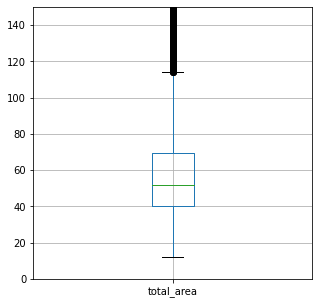

In [40]:
# строим боксплот ("ящик с усами") и смотрим распределение данных столбца total_area
data.boxplot('total_area', figsize=(5, 5))
plt.ylim(0, 150); 

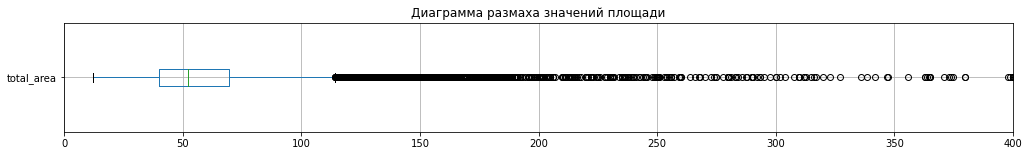

In [41]:
# check
# для примера горизонтальный вид диаграммы размаха

fig, ax = plt.subplots(figsize = (17,2))
ax = data[['total_area']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений площади')
ax.set_xlim(0, 400);

По боксплоту видно:
1) конец нижнего уса - минимальное значение, равное 12 м² \
2) конец верхнего уса равен 114.25 м² - это 1,5 межквартильного размаха, добавленного к 3-му квартилю (здесь и далее значения считала вручную по формуле: , где k - коэффициент, наиболее часто употребляемое значение которого равно 1,5. Это ориентировочная граница нормального размаха; \
3) всё, что выше верхнего уса - выбросы; \
4) так как медиана (зеленая линия) находится достаточно далеко от конца верхнего уса, значит, выбросы все же достаточно редкие; при этом она почти на середине "ящика";\
5) "ящик" ограничен первым и третьим квартилями и отображает межквартильный размах, который равен 29.7 м²;\
6) наблюдается некоторая асимметрии в данных, так как верхний ус чуть длиннее нижнего; \
7) размах вариации или размах стандартного значения - это расстояние между концом нижнего уса и концом верхнего, которое равно 102,25 м².


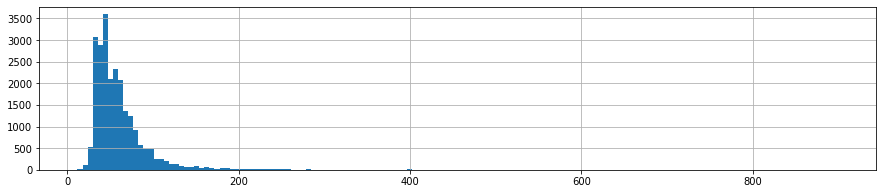

In [42]:
# смотрим распределение данных столбца total_area
data['total_area'].hist(bins = 150, figsize = (15,3));

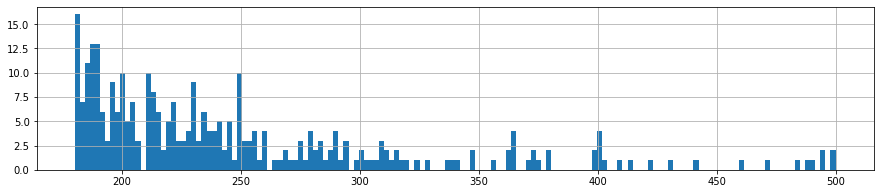

In [43]:
data['total_area'].hist(bins = 150, figsize = (15,3), range = (180,500));

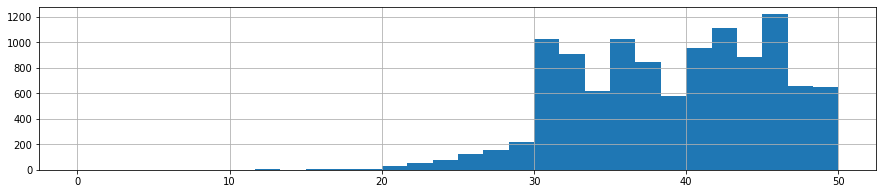

In [44]:
data['total_area'].hist(bins = 30, figsize = (15,3), range = (0,50));

 Получается, все квартиры менее 20 и более 250 квадратных метров можно считать редкостями

In [45]:
print(len(data))

23565


In [46]:
# обрабатываем выбивающиеся значения

# сохраняем данные в новый датафрейм, убирая выбросы по столбцу total_area меньше 20 м и больше 250 м, 
# но сохраняя при этом строки с NaN
data_filtered = data.loc[((data['total_area'] >= 20) & (data['total_area'] <= 250)) | (data['total_area'].isnull())]

In [47]:
# проверяем, процент оставшихся строк
# процент оставшихся строк после предыдущего удаления равен 99.4%
data_len_2 = len(data_filtered)
print((data_len_2/data_len_1)*100)
print(len(data_filtered))

98.85227224777417
23427


На этом шаге удалили 0.6% данных

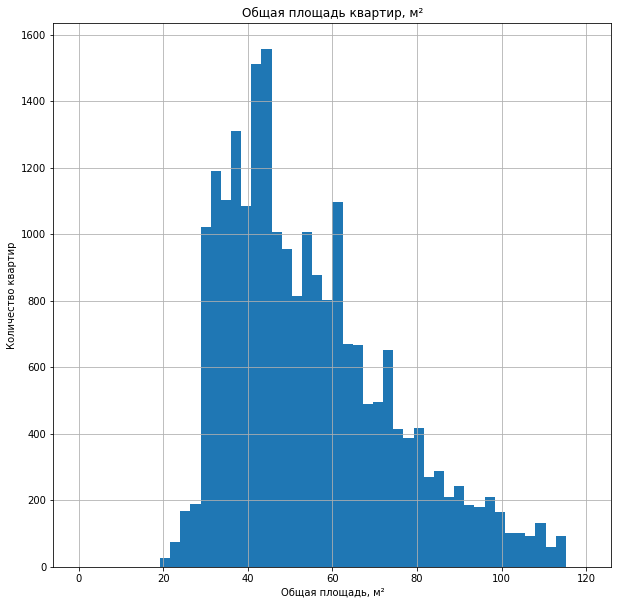

In [48]:
# делаем срез данных до значения общей площади квартир в 115 м², так как
# значения выше этого - выбросы
total_area_slice = data_filtered.query('total_area <= 115') 

# строим гистограмму и смотрим распределение данных столбца total_area
total_area_slice['total_area'].hist(bins=50, range = (0, 120), figsize=(10, 10))
plt.title('Общая площадь квартир, м²')
plt.xlabel('Общая площадь, м²')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Мы видим, что гистограмма смещена вправо (асимметрия вправо).\
Пик - наибольшее количество квартир - приходится на площадь примерно от 42 до 45 м². \
Так же есть пики поменьше - примерно на 37 м², 31 м², 61м².

##### Жилая площадь

In [49]:
# изучаем характеристики, дающие представление о выборке по столбцу living_area
print(data_filtered['living_area'].describe())

count    23427.000000
mean        33.810013
std         18.824467
min          2.000000
25%         19.000000
50%         30.000000
75%         42.000000
max        220.000000
Name: living_area, dtype: float64


Показатель стандартного отклонения высокий (18.8) - это значит, что в наборе данных могут быть аномалии или выбросы.\
Минимальная жилая площадь квартиры - 2 м², похоже на аномалию - слишком маленькая площадь.\
Максимальная - 220 м² - похоже на выброс.\
Медиана - 30 м², а среднее арифметическое равно 33.8 м², разница небольшая, значит, выбросов мало.\
Первый квартиль равен 19 м², ниже него находится четверть (25%) данных об общей площади квартиры или три четверти (75%) данных выше него. То есть 25% квартир имеют жилую площадь менее 19 м².\
Третий квартиль равен 42 м², ниже него находится три четверти (75%) данных об общей площади квартиры или четверть (25%) данных выше него. То есть 25% квартир имеют жилую площадь более 42 м².

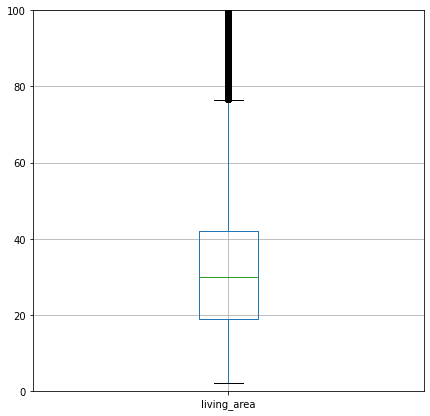

In [50]:
# строим боксплот и смотрим распределение данных столбца living_area
data_filtered.boxplot('living_area', figsize=(7, 7))
plt.ylim(0, 100);

Боксплот:

1) конец нижнего уса - нормальное минимальное значение, равное 2 м²;\
2) конец верхнего уса равен 76.75 м², выше - выбросы;\
3) так как медиана находится достаточно далеко от конца верхнего уса и на середине "ящика", значит, выбросы редкие;\
4) межквартильный размах равен 23.1 м²;\
5) наблюдается асимметрия в данных, так как верхний ус длиннее нижнего почти в 2 раза;\
6) размах вариации или размах стандартного значения равен 74.75 м².

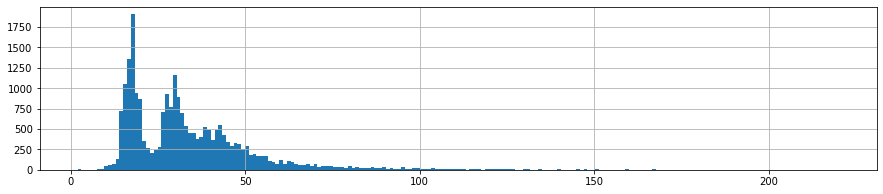

In [51]:
# смотрим распределение данных столбца living_area
data_filtered['living_area'].hist(bins = 200, figsize = (15,3));

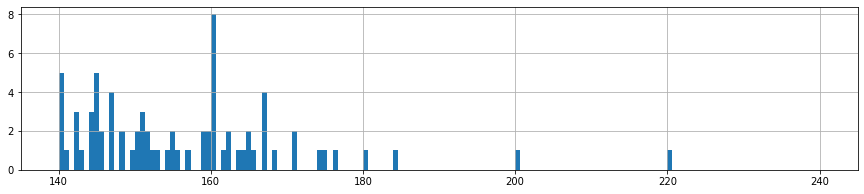

In [52]:
data_filtered['living_area'].hist(bins = 150, figsize = (15,3), range = (140,240));

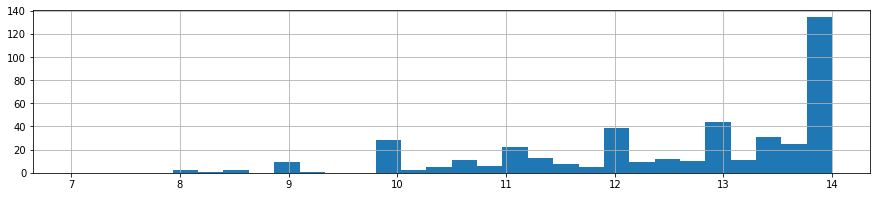

In [53]:
data_filtered['living_area'].hist(bins = 30, figsize = (15,3), range = (7,14));

Квартиры с жилой площадью больше 160 м² и меньше 12 м², за исключением 160 и 12 м², можно считать редкими.

In [54]:
# обрабатываем выбивающиеся значения

# убираем выбросы по столбцу living_area меньше 12 м² и больше 160 м², 
# но сохраняя при этом строки с NaN
data_filtered = data_filtered.loc[((data_filtered['living_area'] >= 12) & (data_filtered['living_area'] <= 160)) \
                                  | (data_filtered['living_area'].isnull())]

In [55]:
# проверяем, процент оставшихся строк
# процент оставшихся строк после предыдущего удаления равен 98.8%
data_len_2 = len(data_filtered)
print((data_len_2/data_len_1)*100)
print(len(data_filtered))

98.22777332376893
23279


На этом шаге удалили 0.6% данных

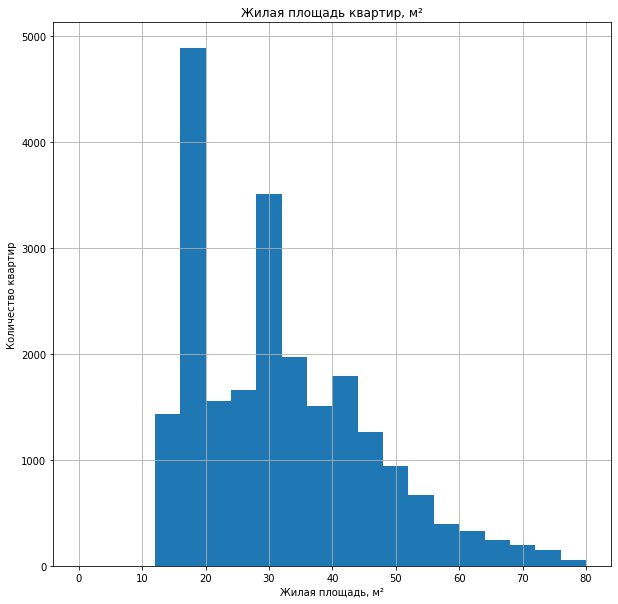

In [56]:
# делаем срез данных до значения жилой площади квартир в 77 м², так как
# значения выше этого - выбросы
living_area_slice = data_filtered.query('living_area <= 77') 

# строим гистограмму и смотрим распределение данных столбца living_area
living_area_slice['living_area'].hist(bins=20, range = (0, 80), figsize=(10, 10))
plt.title('Жилая площадь квартир, м²')
plt.xlabel('Жилая площадь, м²')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Пик - наибольшее количество квартир - приходится на жилую площадь примерно от 15 до 20 м².\
Так же есть пик поменьше - примерно на 27-33 м².

##### Площадь кухни

In [57]:
# изучаем характеристики, дающие представление о выборке по столбцу kitchen_area
print(data_filtered['kitchen_area'].describe())

count    23279.000000
mean        10.405017
std          5.528981
min          1.300000
25%          7.000000
50%          9.000000
75%         12.000000
max        107.000000
Name: kitchen_area, dtype: float64


Показатель стандартного отклонения довольно низкий (5.5) - это значит, что в наборе данных почти нет аномалий или выбросов.\
Минимальная площадь кухни - 1.3 м².\
Максимальная - 107 м² - похоже на выброс.\
Медиана - 9 м², а среднее арифметическое равно 10.4 м², разница небольшая, значит, выбросов мало.\
Первый квартиль равен 7 м², то есть 25% квартир имеют площадь кухни менее 7 м².\
Третий квартиль равен 12 м², то есть 25% квартир имеют площадь кухни более 12 м².

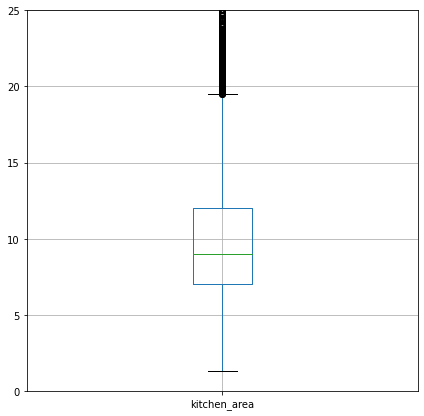

In [58]:
# строим боксплот и смотрим распределение данных столбца kitchen_area
data_filtered.boxplot('kitchen_area', figsize=(7, 7))
plt.ylim(0, 25); 

Боксплот: 

1) конец нижнего уса - нормальное минимальное значение, равное 1.3 м²;\
2) конец верхнего уса равен 19.5 м², выше - выбросы;\
3) так как медиана находится далеко от конца верхнего уса и почти на середине "ящика", значит, выбросы редкие;\
4) межквартильный размах равен 5 м²;\
5) наблюдается небольшая асимметрия в данных, так как верхний ус чуть длиннее нижнего;\
6) размах вариации или размах стандартного значения равен 18.2 м².

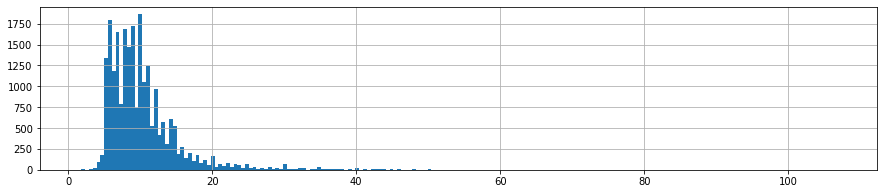

In [59]:
# смотрим распределение данных столбца kitchen_area
data_filtered['kitchen_area'].hist(bins = 200, figsize = (15,3));

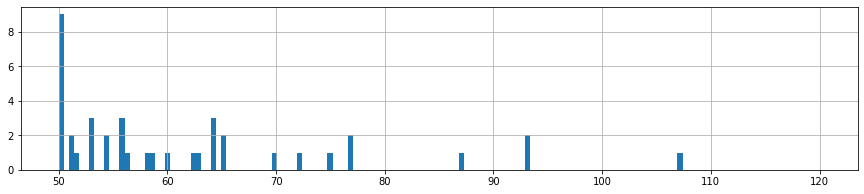

In [60]:
data_filtered['kitchen_area'].hist(bins = 150, figsize = (15,3), range = (50,120));

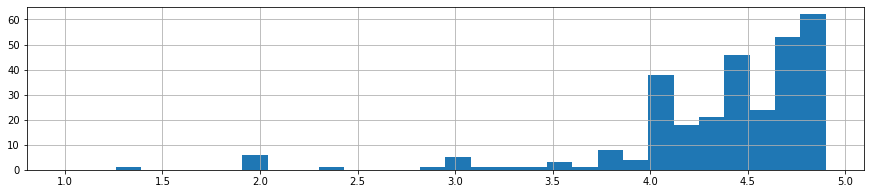

In [61]:
data_filtered['kitchen_area'].hist(bins = 30, figsize = (15,3), range = (1,4.9));

Квартиры с площадью кухни больше 50 м² и меньше 4 м², за исключением 50 и 4 м², можно считать редкими.

In [62]:
# обрабатываем выбивающиеся значения

# убираем выбросы по столбцу kitchen_area меньше 4 м² и больше 50 м², 
# но сохраняя при этом строки с NaN
data_filtered = data_filtered.loc[((data_filtered['kitchen_area'] >= 4) & (data_filtered['kitchen_area'] <= 50)) \
                                   | (data_filtered['kitchen_area'].isnull())]

In [63]:
# проверяем, процент оставшихся строк
# процент оставшихся строк после предыдущего удаления равен 98.2%
data_len_2 = len(data_filtered)
print((data_len_2/data_len_1)*100)
print(len(data_filtered))

97.94506097303683
23212


На этом шаге удалили 0.3% данных

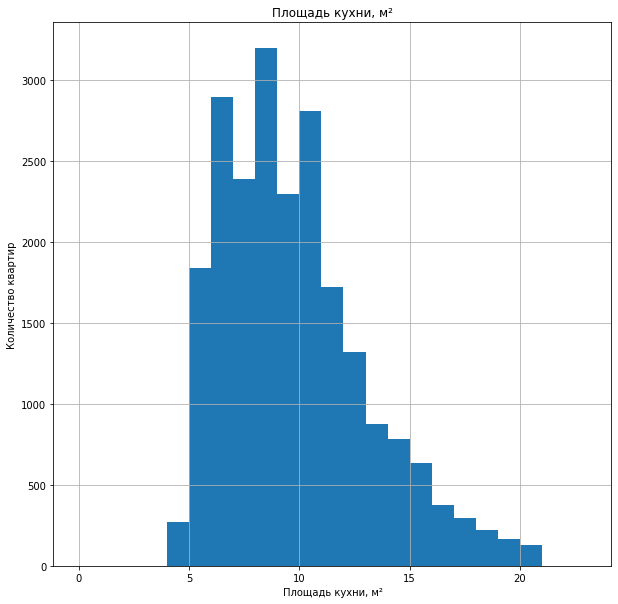

In [64]:
# делаем срез данных до значения площади кухни в 20 м², так как
# значения выше этого - выбросы
kitchen_area_slice = data_filtered.query('kitchen_area <= 20') 

# строим гистограмму и смотрим распределение данных столбца kitchen_area
kitchen_area_slice['kitchen_area'].hist(bins=23, range = (0, 23), figsize=(10, 10))
plt.title('Площадь кухни, м²')
plt.xlabel('Площадь кухни, м²')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Пик - наибольшее количество квартир - приходится на площадь кухни примерно в 8-9 м².\
Так же есть пики поменьше - примерно на 6-7 м² и 10-11 м².

##### Цена объекта

In [65]:
# создаем дополнительный столбец, где стоимость квартир переводим в млн
data_filtered['last_price_mln'] = data_filtered['last_price'] / 1000000

# изучаем характеристики, дающие представление о выборке по столбцу last_price_mln
print(data_filtered['last_price_mln'].describe())

count    23212.000000
mean         6.122201
std          6.670616
min          0.012190
25%          3.420000
50%          4.600000
75%          6.700000
max        330.000000
Name: last_price_mln, dtype: float64


Показатель стандартного отклонения не низкий (6.6) - это значит, что в наборе данных почти нет аномалий или выбросов.\
Минимальная стоимость объекта - 0.012 млн.\
Максимальная - 330 млн - похоже на выброс.\
Медиана - 4.6 млн, а среднее арифметическое равно 6.1 млн, разница небольшая, значит, выбросов мало.\
Первый квартиль равен 3.4 млн, то есть 25% объектов стоили менее 3.4 млн.\
Третий квартиль равен 6.7 млн, то есть 25% квартир стоили более 6.7 млн.

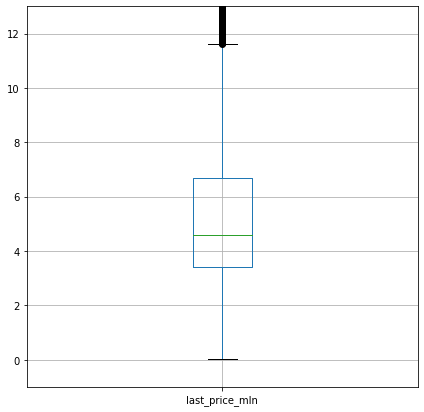

In [66]:
# строим боксплот и смотрим распределение данных столбца last_price_mln
data_filtered.boxplot('last_price_mln', figsize=(7, 7))
plt.ylim(-1, 13); 

Боксплот:

1) конец нижнего уса - нормальное минимальное значение, равное 0.012 млн;\
2) конец верхнего уса равен 11.9 млн, выше - выбросы;\
3) так как медиана находится далеко от конца верхнего уса, значит, выбросы редкие;\
4) межквартильный размах равен 3.39 млн;\
5) наблюдается небольшая асимметрия в данных, так как верхний ус чуть длиннее нижнего;\
6) размах вариации или размах стандартного значения равен 11.888 млн.

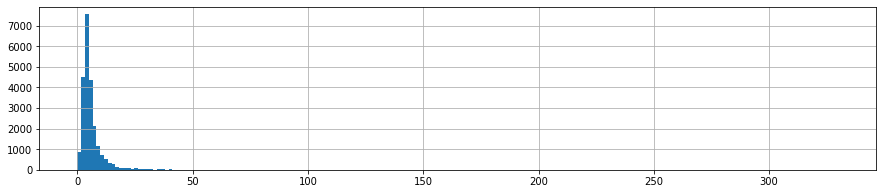

In [67]:
# смотрим распределение данных столбца last_price_mln
data_filtered['last_price_mln'].hist(bins = 200, figsize = (15,3));

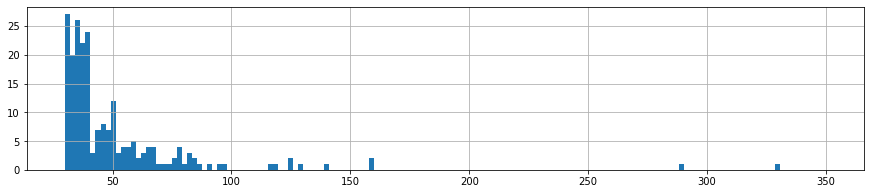

In [68]:
data_filtered['last_price_mln'].hist(bins = 150, figsize = (15,3), range = (30,350));

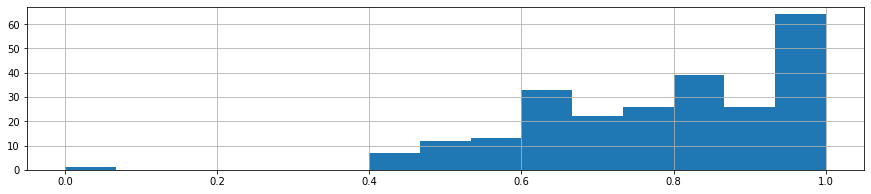

In [69]:
data_filtered['last_price_mln'].hist(bins = 15, figsize = (15,3), range = (0,1));

Квартиры со стоимостью больше 50 млн и меньше 0.8 млн можно считать редкими.

In [70]:
# обрабатываем выбивающиеся значения

# убираем выбросы по столбцу last_price_mln меньше 0.8 млн и больше 50 млн, 
# но сохраняя при этом строки с NaN
data_filtered = data_filtered.loc[((data_filtered['last_price_mln'] >= 0.8) & (data_filtered['last_price_mln'] <= 50)) \
                                   | (data_filtered['last_price_mln'].isnull())]

In [71]:
# проверяем, процент оставшихся строк
# процент оставшихся строк после предыдущего удаления равен 97.9%
data_len_2 = len(data_filtered)
print((data_len_2/data_len_1)*100)
print(len(data_filtered))

97.21085277859825
23038


На этом шаге удалили 0.7% данных

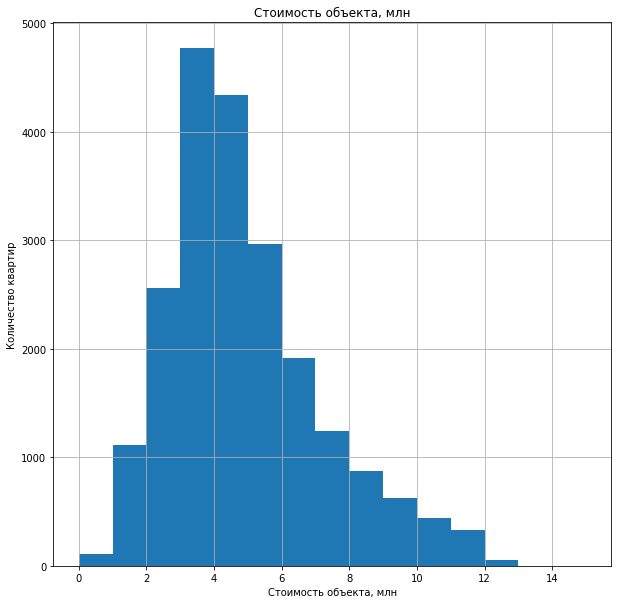

In [72]:
# делаем срез данных до значения стоимости в 12 млн, так как
# значения выше этого - выбросы
last_price_mln_slice = data_filtered.query('last_price_mln <= 12')

# строим гистограмму и смотрим распределение данных столбца last_price_mln
last_price_mln_slice['last_price_mln'].hist(bins=15, range = (0, 15), figsize=(10, 10))
plt.title('Стоимость объекта, млн')
plt.xlabel('Стоимость объекта, млн')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Гистограмма нормального распределения.\
Наибольшее количество квартир стоило 3-4 млн.

##### Количество комнат

In [73]:
# изучаем характеристики, дающие представление о выборке по столбцу rooms
print(data_filtered['rooms'].describe())


count    23038.000000
mean         2.051567
std          1.011947
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: rooms, dtype: float64


Показатель стандартного отклонения очень низкий (1) - это значит, что в наборе данных практически нет аномалий или выбросов.\
Минимальное количество комнат - 0, то есть есть объекты, где комнаты отсутствуют.\
Максимальное - 11.\
Медиана - 2, среднее арифметическое тоже равно 2, разницы нет, значит, выбросов или нет, или их очень мало.\
Первый квартиль равен 1, то есть 25% квартир имеют 1 или менее комнат.\
Третий квартиль равен 3, то есть 25% квартир имеют более 3 комнат.

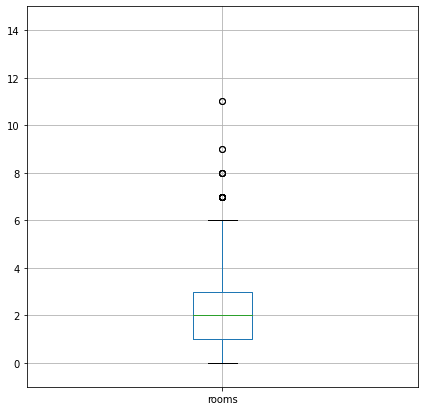

In [74]:
# строим боксплот и смотрим распределение данных столбца rooms
data_filtered.boxplot('rooms', figsize=(7, 7))
plt.ylim(-1, 15); 

Боксплот: 

1) конец нижнего уса - нормальное минимальное значение, равное 0;\
2) конец верхнего уса равен 6, выше - выбросы, которых очень мало, поэтому они обозначены не сплошной линией, а точками;\
3) так как медиана находится далеко от конца верхнего уса и на середине "ящика", значит, выбросов очень мало;\
4) межквартильный размах равен 2;\
5) наблюдается асимметрия в данных, так как верхний ус длиннее нижнего в 3 раза;\
6) размах вариации или размах стандартного значения равен 6.

In [75]:
data_filtered.rooms.value_counts().to_frame()

,rooms
2,7818
1,7797
3,5726
4,1127
5,282
0,175
6,73
7,31
8,5
9,2


Квартир с количеством комнат больше 7 очень мало, поэтому уберем их как выбросы

In [76]:
# убираем выбросы по столбцу rooms больше 7 квартир, 
# но сохраняя при этом строки с NaN
data_filtered = data_filtered.loc[(data_filtered['rooms'] <= 7) | (data_filtered['rooms'].isnull())]

In [77]:
# проверяем, процент оставшихся строк
# процент оставшихся строк после предыдущего удаления равен 97.2%
data_len_2 = len(data_filtered)
print((data_len_2/data_len_1)*100)
print(len(data_filtered))

97.17287649267902
23029


На этом шаге удалили 0.1% данных

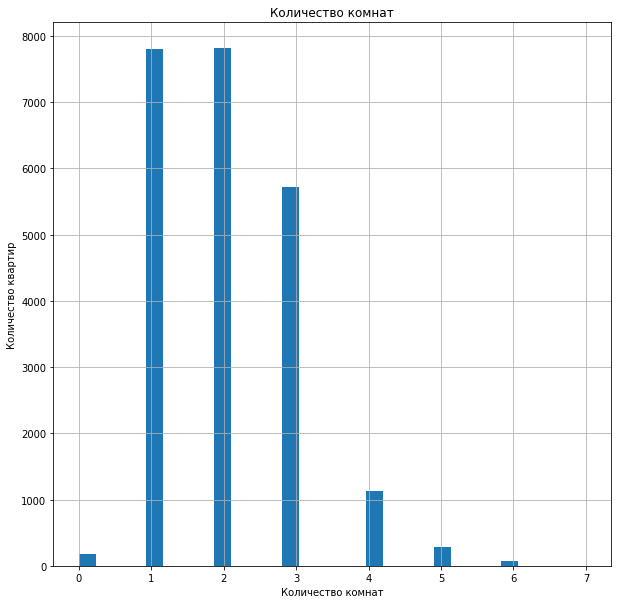

In [78]:
# делаем срез данных до значения количества комнат в 6 штук, так как
# значения выше этого - выбросы
rooms_slice = data_filtered.query('rooms <= 6') 

# строим гистограмму и смотрим распределение данных столбца rooms
rooms_slice['rooms'].hist(bins=30, range = (0, 7), figsize=(10, 10))
plt.title('Количество комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Асимметрия вправо.\
В наибольшем количестве квартир 2 комнаты, чуть реже 1.


##### Высота потолков

In [79]:
# изучаем характеристики, дающие представление о выборке по столбцу ceiling_height
print(data_filtered['ceiling_height'].describe())

count    14177.000000
mean         2.764999
std          1.272024
min          1.000000
25%          2.510000
50%          2.650000
75%          2.800000
max        100.000000
Name: ceiling_height, dtype: float64


In [80]:
# так как прослеживаются аномалии в высоте потолков, например, 100 м, приняла 
# это за ошибку и решила перезаписать столбец, разделив значения больше 20 м 
# на 10 (скорее всего 100м -это 10.0 м, а 25м - это 2.5 м)
data_filtered.loc[(data_filtered['ceiling_height'] >= 20), 'ceiling_height'] = \
data_filtered.loc[(data_filtered['ceiling_height'] >= 20), 'ceiling_height'] / 10

In [81]:
# изучаем характеристики, дающие представление о выборке по столбцу 
# ceiling_height 
print(data_filtered['ceiling_height'].describe())


count    14177.000000
mean         2.722141
std          0.308489
min          1.000000
25%          2.500000
50%          2.650000
75%          2.800000
max         14.000000
Name: ceiling_height, dtype: float64


Показатель стандартного отклонения низкий (0.3) - это значит, что в наборе данных почти нет выбросов.\
Минимальная высота потолков - 1 м.\
Максимальная - 14 м - похоже на выброс.\
Медиана - 2.65 м, а среднее арифметическое равно 2.7 м, разница небольшая, значит, выбросов мало.\
Первый квартиль равен 2.5 м, то есть 25% квартир имеют высоту потолков менее 2.5 м.\
Третий квартиль равен 2.8 м, то есть 25% квартир имеют высоту потолков более 2.8 м.

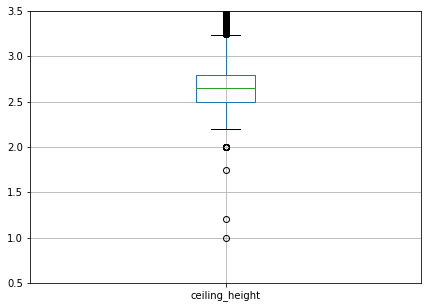

In [82]:
data_filtered.boxplot('ceiling_height', figsize=(7, 5))
plt.ylim(0.5, 3.5); 

Боксплот:

1) конец нижнего уса - нормальное минимальное значение, равное 2.075 м (подсчитано по формуле, коэффициент 1.5) НО не сходится с значением на графике боксплота, где оно равно примерно 2.28 м), ниже - выбросы;\
2) конец верхнего уса равен 3.235 м, выше - выбросы;\
3) так как медиана находится далеко от конца верхнего уса и на середине "ящика", значит, выбросы редкие;\
4) межквартильный размах равен 0.29 м;\
5) наблюдается небольшая асимметрия в данных, так как верхний ус чуть длиннее нижнего;\
6) размах вариации или размах стандартного значения равен 0.955 м (если границу нижнего уса брать по боксплоту, а не по расчетам по формуле).

Считала значение нижнего уса по формуле X1 = Q1-k(Q3-Q1), где k брала равным 1.5:\
X1 = 2.51 - 1.5 * (2.8-2.51) = 2.51 - 0.435 = 2.075\
Расчитанное вручную значение не сходится с примерным значением нижнего уса боксплота по графику.\
Что может быть причиной?


In [83]:
# check
data['total_area'].describe()

count    23565.000000
mean        60.322824
std         35.657060
min         12.000000
25%         40.000000
50%         52.000000
75%         69.700000
max        900.000000
Name: total_area, dtype: float64

In [84]:
# check
40-1.5*(69.7-40)

-4.550000000000004

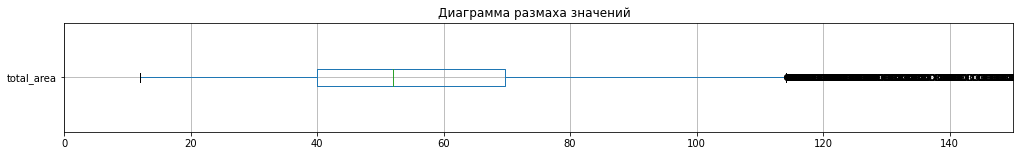

In [85]:
# check 

fig, ax = plt.subplots(figsize = (17,2))
ax = data[['total_area']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений  ')
ax.set_xlim(0, 150);

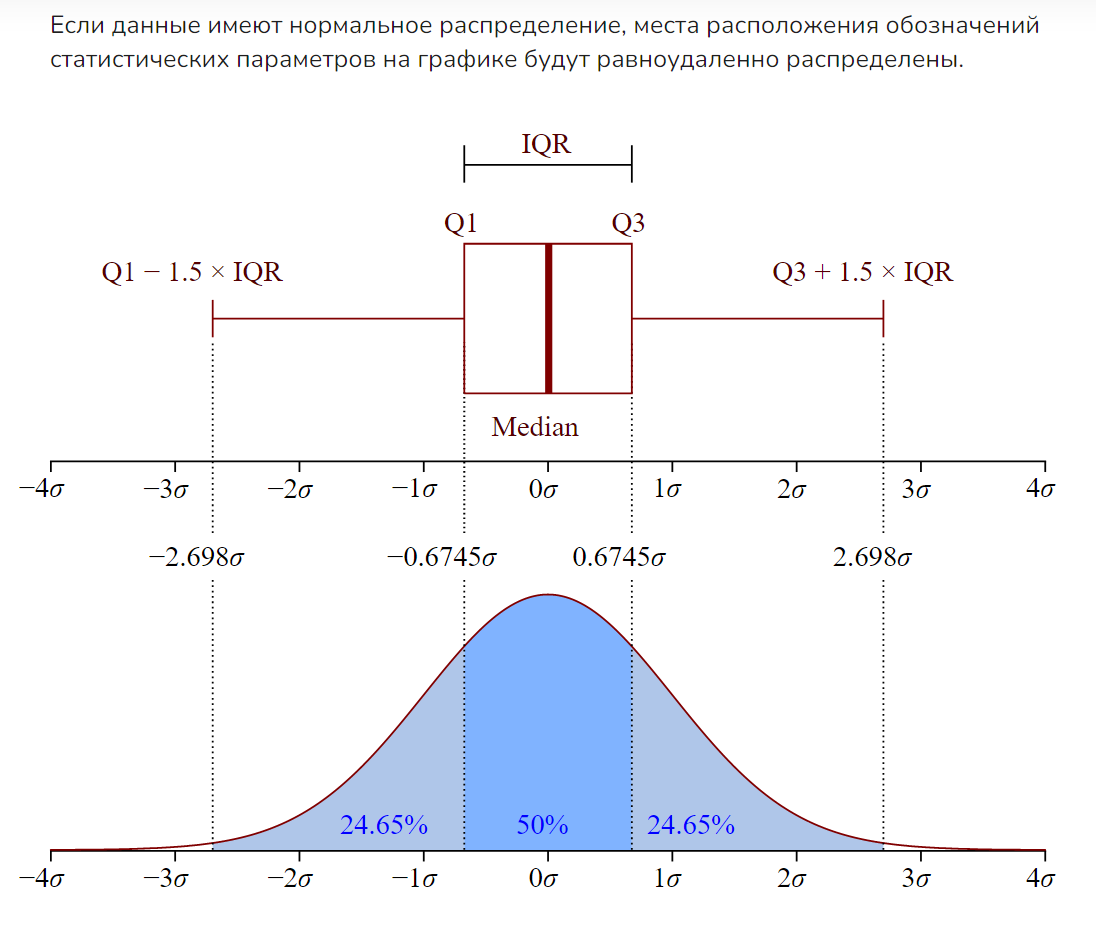

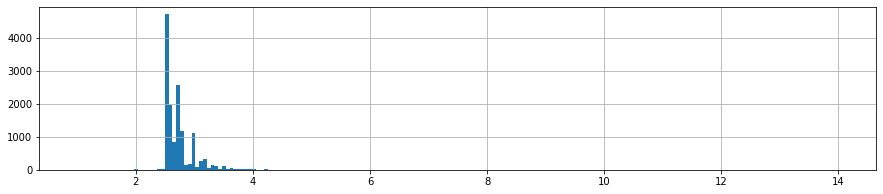

In [86]:
# смотрим распределение данных столбца ceiling_height
data_filtered['ceiling_height'].hist(bins = 200, figsize = (15,3));

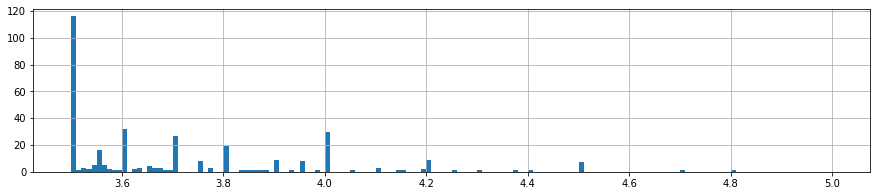

In [87]:
data_filtered['ceiling_height'].hist(bins = 150, figsize = (15,3), range = (3.5,5));

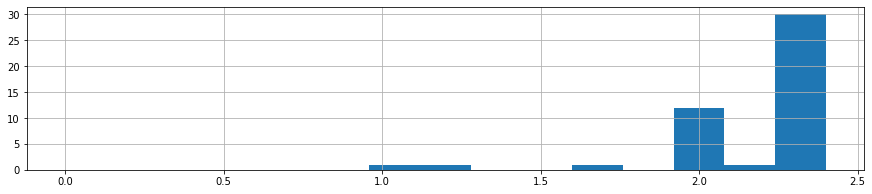

In [88]:
data_filtered['ceiling_height'].hist(bins = 15, figsize = (15,3), range = (0,2.4));

Квартиры с высотой потолков больше 4 м и меньше 2 м можно считать редкими.

In [89]:
# обрабатываем выбивающиеся значения

# убираем выбросы по столбцу ceiling_height меньше 2 м и больше 4 м, 
# но сохраняя при этом строки с NaN
data_filtered = data_filtered.loc[((data_filtered['ceiling_height'] >= 2) & (data_filtered['ceiling_height'] <= 4)) \
                                   | (data_filtered['ceiling_height'].isnull())]

In [90]:
# проверяем, процент оставшихся строк
# процент оставшихся строк после предыдущего удаления равен 97.1%
data_len_2 = len(data_filtered)
print((data_len_2/data_len_1)*100)
print(len(data_filtered))

96.99143423773155
22986


На этом шаге удалили 0.2% данных

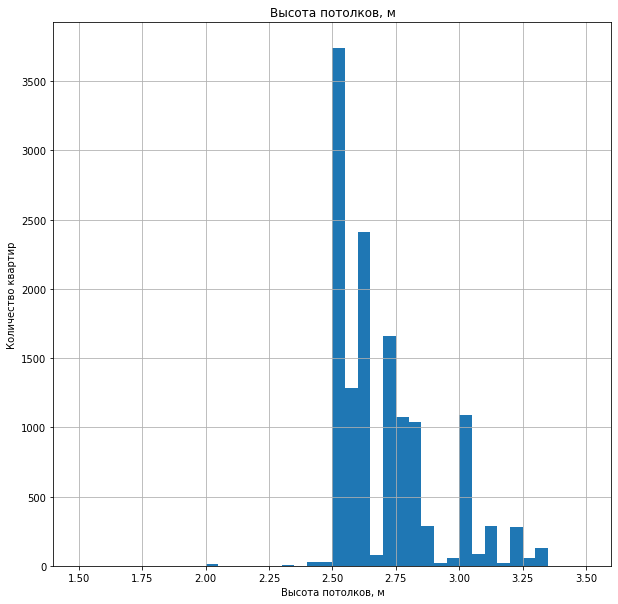

In [91]:
# делаем срез данных до значения высоты потолка в 3.3 м, так как
# значения выше этого - выбросы
ceiling_height_slice = data_filtered.query('ceiling_height <= 3.3') 

# строим гистограмму и смотрим распределение данных столбца ceiling_height
ceiling_height_slice['ceiling_height'].hist(bins=40, range = (1.5, 3.5), figsize=(10, 10))
plt.title('Высота потолков, м')
plt.xlabel('Высота потолков, м')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Пик - наибольшее количество квартир - приходится на высоту потолков примерно в 2.50-2.55 м.\
Так же есть пики поменьше - примерно на 2.6-2.65 м и 2.7-2.75 м.

##### Тип этажа квартиры 

In [92]:
# смотрим количество квартир с разными типами этажа
print(data_filtered['floor_type'].value_counts())

другой       16983
последний     3180
первый        2823
Name: floor_type, dtype: int64


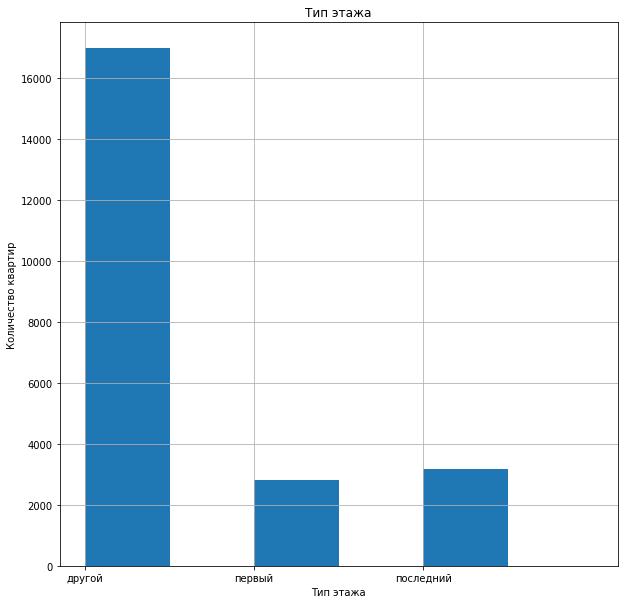

In [93]:
# строим гистограмму и смотрим распределение данных столбца floor_type
data_filtered['floor_type'].hist(bins=6, range = (0, 3), figsize=(10, 10))
plt.title('Тип этажа')
plt.xlabel('Тип этажа')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Пик - наибольшее количество квартир (16983) является ни первыми, ни последними.\
Квартир других типов намного меньше: последних 3180, первых - 2823.

##### Общее количество этажей в доме

In [94]:
# изучаем характеристики, дающие представление о выборке по столбцу floors_total
print(data_filtered['floors_total'].describe())

count    22986.000000
mean        10.738101
std          6.584744
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64


Показатель стандартного отклонения довольно низкий (6.5) - это значит, что в наборе данных почти нет аномалий или выбросов.\
Минимальное количество этажей - 1.\
Максимальное - 60 - похоже на выброс, но не аномалия.\
Медиана - 9, а среднее арифметическое равно 10.7, разница небольшая, значит, выбросов мало.\
Первый квартиль равен 5, то есть 25% квартир находятся в домах, где 5 и менее этажей.\
Третий квартиль равен 16, то есть 25% квартир находятся в домах, где 16 и более этажей.

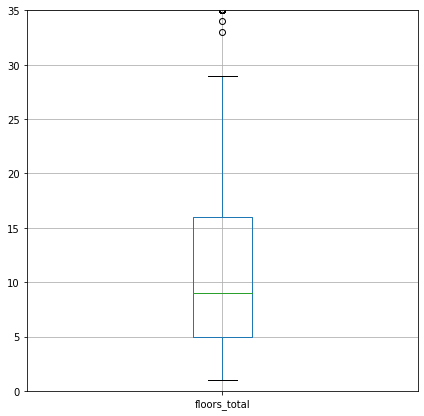

In [95]:
# строим боксплот и смотрим распределение данных столбца floors_total
data_filtered.boxplot('floors_total', figsize=(7, 7))
plt.ylim(0, 35); 

Боксплот: 

1) конец нижнего уса - нормальное минимальное значение, равное 1;\
2) конец верхнего уса равен примерно 29, выше - выбросы;\
3) так как медиана находится далеко от конца верхнего уса, значит, выбросы редкие, но она не на середине "ящика";\
4) межквартильный размах равен 11;\
5) наблюдается асимметрия в данных, так как верхний ус длиннее нижнего в три раза;\
6) размах вариации или размах стандартного значения равен 28.

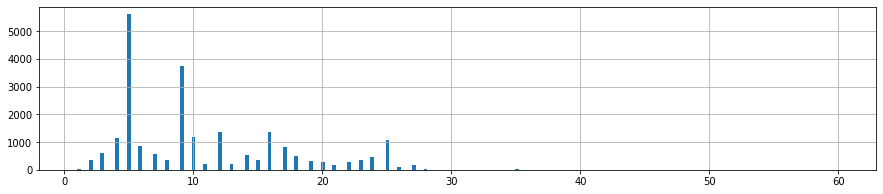

In [96]:
# смотрим распределение данных столбца floors_total
data_filtered['floors_total'].hist(bins = 200, figsize = (15,3));

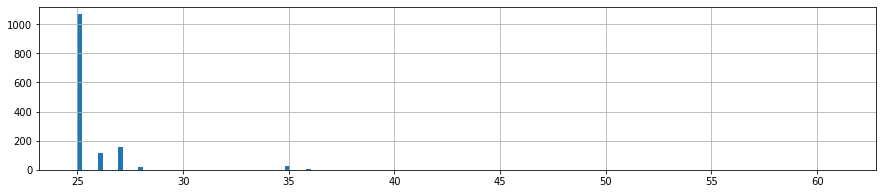

In [97]:
data_filtered['floors_total'].hist(bins = 150, figsize = (15,3), range = (25, 61));

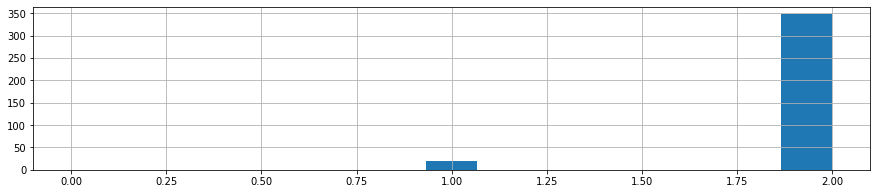

In [98]:
data_filtered['floors_total'].hist(bins = 15, figsize = (15,3), range = (0,2));

Квартиры в домах с количеством этажей больше 26 можно считать редкими.

In [99]:
# обрабатываем выбивающиеся значения

# убираем выбросы по столбцу floors_total больше 26, 
# но сохраняя при этом строки с NaN
data_filtered = data_filtered.loc[(data_filtered['floors_total'] <= 26) | (data_filtered['ceiling_height'].isnull())]

In [100]:
# проверяем, процент оставшихся строк
# процент оставшихся строк после предыдущего удаления равен 96.9%
data_len_2 = len(data_filtered)
print((data_len_2/data_len_1)*100)
print(len(data_filtered))

96.61589096586354
22897


На этом шаге удалили 0.3% данных

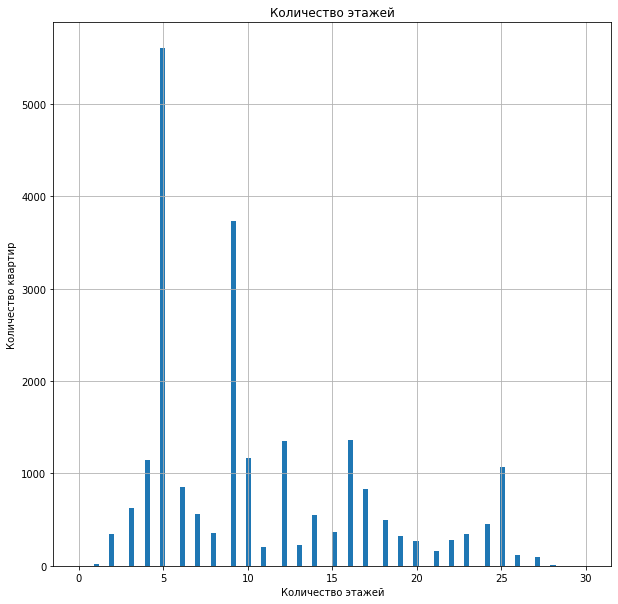

In [101]:
# делаем срез данных до значений количества этажей в 29, так как
# значения выше этого - выбросы
floors_total_slice = data_filtered.query('floors_total <= 29')

# строим гистограмму и смотрим распределение данных столбца kitchen_area
floors_total_slice['floors_total'].hist(bins=100, range = (0, 30), figsize=(10, 10))
plt.title('Количество этажей')
plt.xlabel('Количество этажей')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Наблюдаются несколько разрозненных пиков: \
наивысший - 5 этажей;\
второй по высоте - 9 этажей.
Остальные пики сильно ниже.

##### Расстояние до центра города

In [102]:
# изучаем характеристики, дающие представление о выборке по столбцу city_centers_nearest
print(data_filtered['city_centers_nearest'].describe())

count    17594.000000
mean     14294.520462
std       8601.395581
min        181.000000
25%       9467.000000
50%      13149.000000
75%      16293.000000
max      65968.000000
Name: city_centers_nearest, dtype: float64


Показатель стандартного отклонения очень высокий (8601) - это значит, что в наборе данных очень много аномалий или выбросов.\
Минимальное расстояние до центра города - 181 м.\
Максимальное - 65968 м - похоже на выброс.\
Медиана - 13149 м, а среднее арифметическое равно 14294 м.\
Первый квартиль равен 9467 м, то есть 25% квартир находятся на расстоянии менее 9467 м от центра города.\
Третий квартиль равен 16293 м, то есть 25% квартир находятся на расстоянии более 16293 м от центра города.

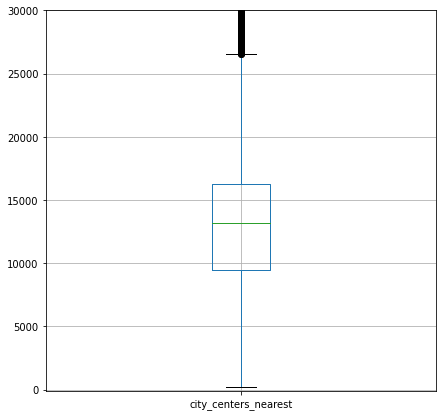

In [103]:
# строим боксплот и смотрим распределение данных столбца city_centers_nearest
data_filtered.boxplot('city_centers_nearest', figsize=(7, 7))
plt.ylim(-100, 30000); 

Боксплот:

1) конец нижнего уса - нормальное минимальное значение, равное 181 м;\
2) конец верхнего уса равен 26855 м, выше - выбросы;\
3) медиана находится примерно одинаково далеко от концов усов и почти на середине "ящика";\
4) межквартильный размах равен 7047 м;\
5) асимметрия в данных практически не наблюдается, так как усы практически одинаковой длины;\
6) размах вариации или размах стандартного значения равен 26674 м.

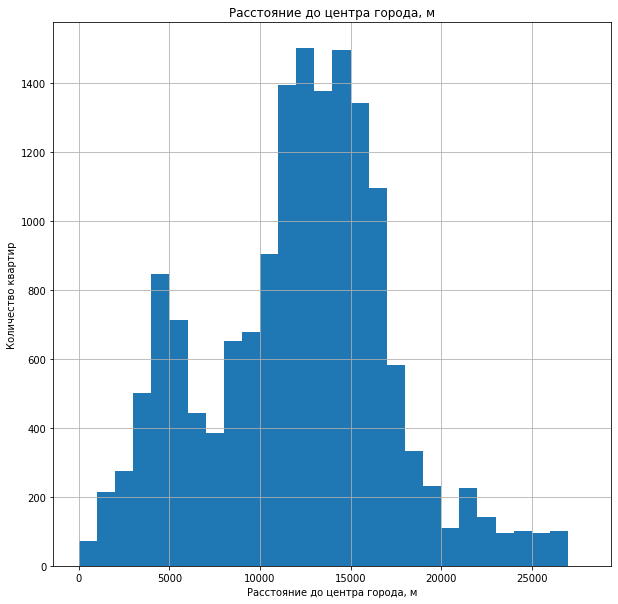

In [104]:
# делаем срез данных до значения расстояния до центра города 
# в 27000 м, так как значения выше этого - выбросы
city_centers_nearest_slice = data_filtered.query('city_centers_nearest <= 27000')

# строим гистограмму и смотрим распределение данных столбца cityCenters_nearest
city_centers_nearest_slice['city_centers_nearest'].hist(bins=28, range = (0, 28000), figsize=(10, 10))
plt.title('Расстояние до центра города, м')
plt.xlabel('Расстояние до центра города, м')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Бимодальное распределение (?).\
Два наивысших пика - наибольшее количество квартир находится на расстоянии примерно в 12000-13000 м и 14000-15000 м от центра города, широкий горб при этом указывает на большое количество квартир, которые находятся на расстоянии 11000-16000м от центра города.\
Так же есть пик другого горба,он указывает на расстояние до центра города в примерно 4000-5000 м.

##### Расстояние до ближайшего парка

In [105]:
# изучаем характеристики, дающие представление о выборке по столбцу parks_nearest
print(data_filtered['parks_nearest'].describe())

count    7774.000000
mean      492.274505
std       341.792616
min         1.000000
25%       288.000000
50%       456.000000
75%       613.000000
max      3190.000000
Name: parks_nearest, dtype: float64


Показатель стандартного отклонения высокий (341) - это значит, что в наборе данных много аномалий или выбросов.\
Минимальное расстояние до ближайшего парка - 1 м.\
Максимальное - 3190 м, похоже на выброс.\
Медиана - 456 м, а среднее арифметическое равно 492 м.\
Первый квартиль равен 288 м, то есть 25% квартир находятся на расстоянии менее 288 м до ближайшего парка.\
Третий квартиль равен 613 м, то есть 25% квартир находятся на расстоянии более 613 м до ближайшего парка.

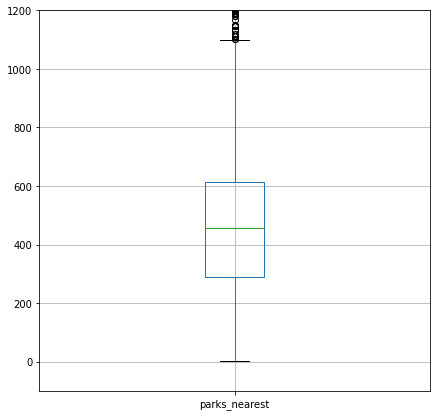

In [106]:
# строим боксплот и смотрим распределение данных столбца parks_nearest
data_filtered.boxplot('parks_nearest', figsize=(7, 7))
plt.ylim(-100, 1200); 

Боксплот:

1) конец нижнего уса - нормальное минимальное значение, равное 1 м;\
2) конец верхнего уса равен 1098 м, выше - выбросы;\
3) медиана находится далеко от конца верхнего уса и почти на середине "ящика";\
4) межквартильный размах равен 324 м;\
5) наблюдается небольшая асимметрия в данных, так как верхний ус чуть длиннее нижнего;\
6) размах вариации или размах стандартного значения равен 1097 м.

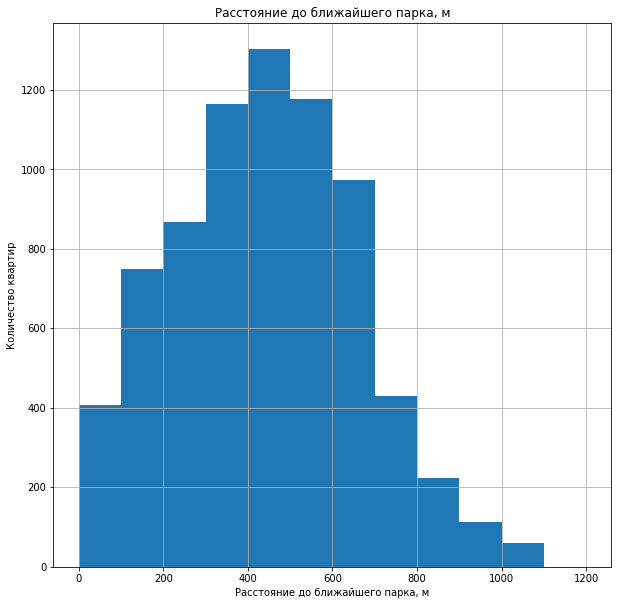

In [107]:
# делаем срез данных до значения расстояния в 1100 м, так как
# значения выше этого - выбросы
parks_nearest_slice = data_filtered.query('parks_nearest <= 1100')

# строим гистограмму и смотрим распределение данных столбца parks_nearest
parks_nearest_slice['parks_nearest'].hist(bins=12, range = (0, 1200), figsize=(10, 10))
plt.title('Расстояние до ближайшего парка, м')
plt.xlabel('Расстояние до ближайшего парка, м')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Нормальное распределение.\
Пик - наибольшее количество квартир находится на расстоянии в 400-500 м от ближайшего парка.

In [108]:
# проверяем процент удаленных данных после предобработки и удаления аномалий
data_len_2 = len(data_filtered)
print(100 - ((data_len_2/data_len_1)*100))

3.3841090341364577


Процент удаленных значений после предобработки и удаления аномалий равен 3.38%.

##### check gap

In [109]:
# check
data_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22897 entries, 0 to 23698
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   total_images             22897 non-null  int64         
 1   last_price               22897 non-null  float64       
 2   total_area               22897 non-null  float64       
 3   first_day_exposition     22897 non-null  datetime64[ns]
 4   rooms                    22897 non-null  int64         
 5   ceiling_height           14045 non-null  float64       
 6   floors_total             22897 non-null  int64         
 7   living_area              22897 non-null  float64       
 8   floor                    22897 non-null  int64         
 9   is_apartment             22897 non-null  bool          
 10  studio                   22897 non-null  bool          
 11  open_plan                22897 non-null  bool          
 12  kitchen_area             22897 n

In [110]:
# check

# Показатели о кол-ве объявлений в датасете, минимальных и максимальных значениях 
# в выбранных параметрах о продаже квартир
# сырые данные

(
    data_filtered[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price_mln', 'living_area',  'kitchen_area',
           'floors_total']]
    .apply (['count', 'min', 'max', 'median'])   # добавила медиану
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,days_exposition,last_price_mln,living_area,kitchen_area,floors_total
count,"22,897.00","22,897.00","14,045.00","19,834.00","22,897.00","22,897.00","22,897.00","22,897.00"
min,0.00,20.00,2.00,1.00,0.80,12.00,4.00,1.00
max,7.00,250.00,4.00,"1,580.00",50.00,160.00,50.00,36.00
median,2.00,52.00,2.65,95.00,4.63,30.00,9.00,9.00


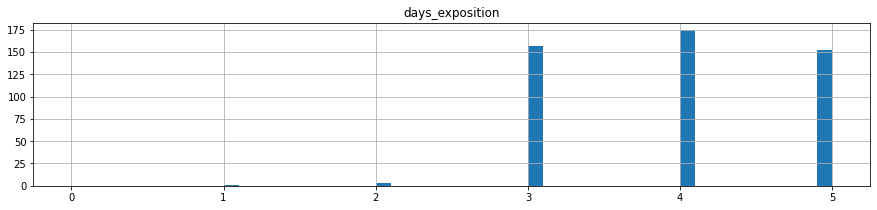

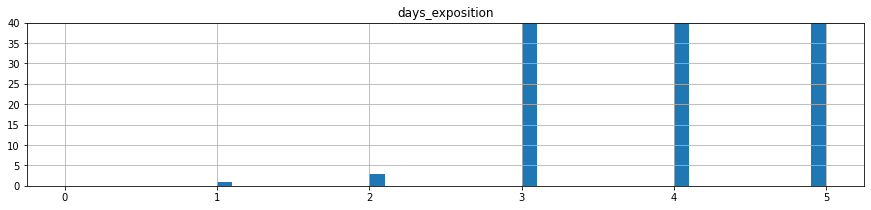

In [111]:
# check
data.hist(column = 'days_exposition', bins = 50, figsize = (15,3), range = (0,5));

data.hist(column = 'days_exposition', bins = 50, figsize = (15,3), range = (0,5))
plt.ylim(0, 40);

In [112]:
# check

try:
    df_check = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')
# если не получилось прочитать файл из локальной папки, то загружаем данные из сети
except:
    df_check = pd.read_csv('real_estate_data.csv', sep='\t')

In [113]:
# check
df_check.rooms.value_counts().to_frame()

,rooms
1,8047
2,7940
3,5814
4,1180
5,326
0,197
6,105
7,59
8,12
9,8


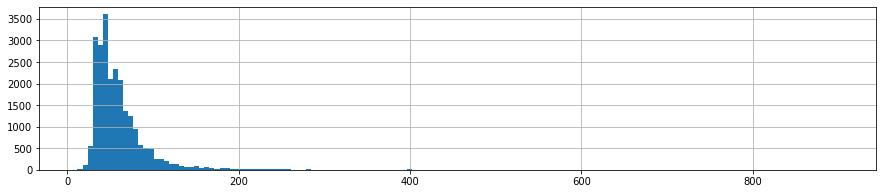

In [114]:
# check
df_check.total_area.hist(bins = 150, figsize = (15,3));

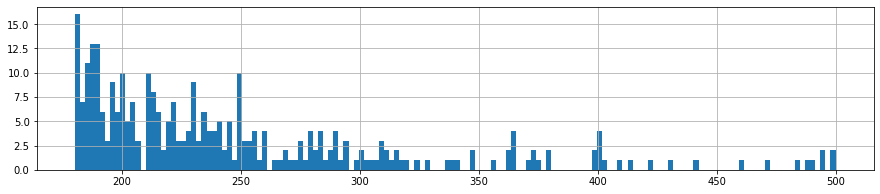

In [115]:
# check
df_check.total_area.hist(bins = 150, figsize = (15,3), range = (180,500));

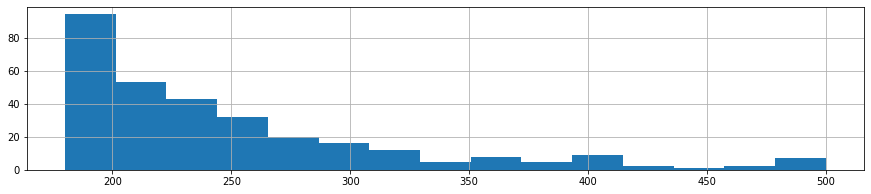

In [116]:
# check
df_check.total_area.hist(bins = 15, figsize = (15,3), range = (180,500));

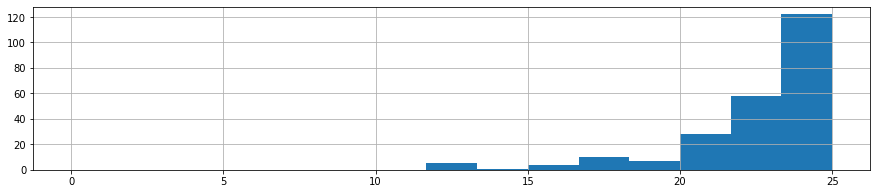

In [117]:
# check
df_check.total_area.hist(bins = 15, figsize = (15,3), range = (0,25));

In [118]:
# check

# Значения параметров объектов недвижимости на разных квантилях

(
    data_filtered[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price', 'living_area',  
        'kitchen_area', 'floor',   'floors_total']]
    .quantile([0.0012, 0.01, .5, .99, .9988]) # выбираем размах в 0,9976 квантилей 
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
0.0012,0.00,22.50,2.30,3.00,"850,000.00",12.00,4.02,1.00,2.00
0.01,1.00,26.23,2.50,4.00,"1,150,000.00",14.00,4.87,1.00,2.00
0.5,2.00,52.00,2.65,95.00,"4,626,540.00",30.00,9.00,4.00,9.00
0.99,5.00,165.00,3.60,"1,069.00","26,478,050.56",100.00,31.47,22.00,26.00
0.9988,7.00,218.57,4.00,"1,373.40","43,715,147.20",144.55,45.00,25.00,28.00


#### Скорость продажи квартир

In [119]:
# изучаем характеристики, дающие представление о выборке по столбцу days_exposition
print(data_filtered['days_exposition'].describe())

count    19834.000000
mean       179.807603
std        219.029002
min          1.000000
25%         45.000000
50%         95.000000
75%        229.000000
max       1580.000000
Name: days_exposition, dtype: float64


Среднее арифметическое равно 179.8 дней, а медиана - 95 дней, следовательно, есть большое количество выбросов, которые так сильно сдвигают показатель среднего.\
Минимальное количество дней, сколько было размещено объявление, - 1 день.\
Максимальное - 1580 дней, а это 4.3 года, - выброс.

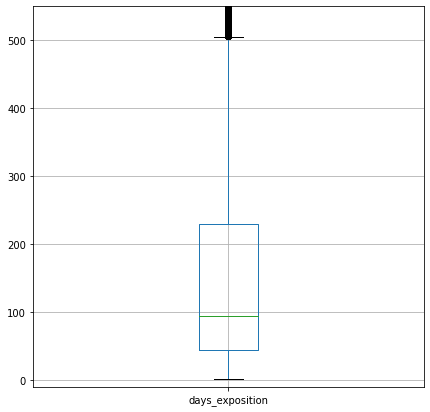

In [120]:
# строим боксплот и смотрим распределение данных столбца days_exposition,
# чтобы определить, за каким значением начинаются выбросы
data_filtered.boxplot('days_exposition', figsize=(7, 7))
plt.ylim(-10, 550);

Выбросами являются значения примерно выше 510 дней, но так как гистограмма имеет длинный правый хвост, будем ориентироваться на значения 0,99 квантиля, это где-то 1200-1300 дней.

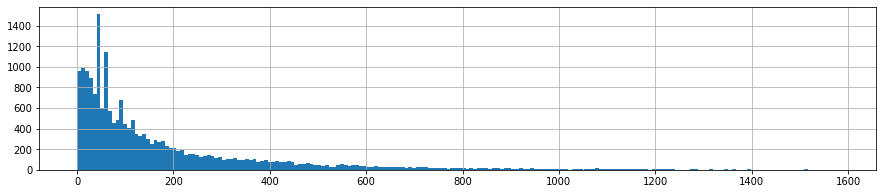

In [121]:
# смотрим распределение данных столбца days_exposition
data_filtered['days_exposition'].hist(bins = 200, figsize = (15,3));

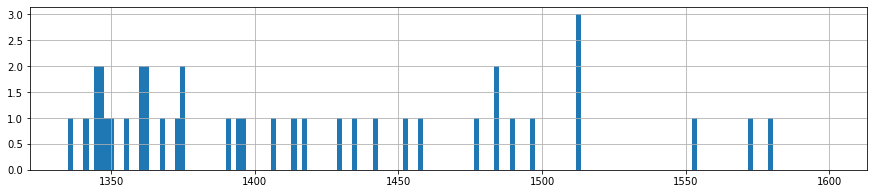

In [122]:
data_filtered['days_exposition'].hist(bins = 150, figsize = (15,3), range = (1335,1600));

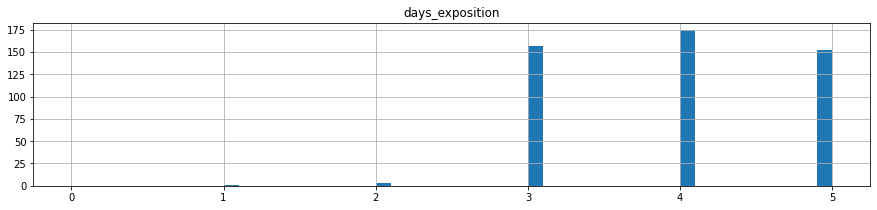

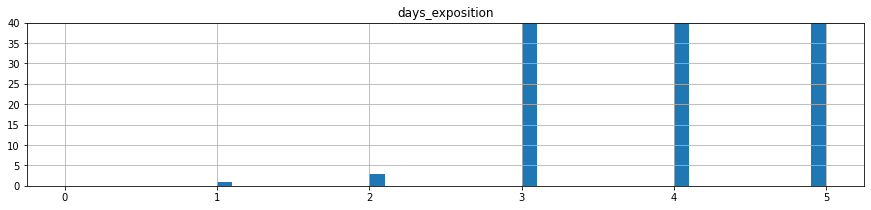

In [123]:
data.hist(column = 'days_exposition', bins = 50, figsize = (15,3), range = (0,5));

data.hist(column = 'days_exposition', bins = 50, figsize = (15,3), range = (0,5))
plt.ylim(0, 40);

Убираем редкие значения 1 и 2 дня и значения больше 1340 дней.

In [124]:
# убираем выбросы по столбцу days_exposition меньше 3 дней, 
# но сохраняя при этом строки с NaN
data_filtered = data_filtered.loc[((data_filtered['days_exposition'] >= 3) & (data_filtered['days_exposition'] <= 1340))\
                                  | (data_filtered['days_exposition'].isnull())]

In [125]:
# проверяем, процент оставшихся строк
# процент оставшихся строк после предыдущего удаления равен 96.6%
data_len_2 = len(data_filtered)
print((data_len_2/data_len_1)*100)

96.43866829824044


На этом шаге удалили 0.2% данных

In [126]:
# проверяем процент удаленных данных после предобработки и удаления аномалий
data_len_2 = len(data_filtered)
print(100 - (data_len_2/data_len_1)*100)

3.5613317017595563


Итого процент удаленных значений после предобработки и удаления аномалий равен 3.5%

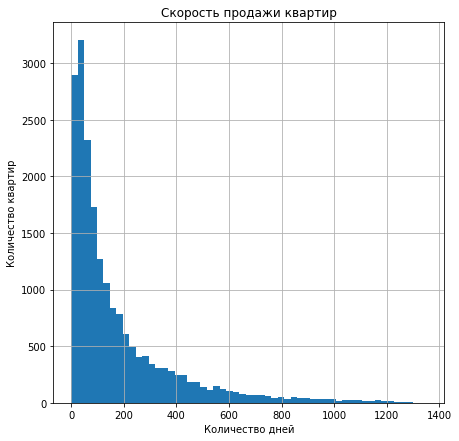

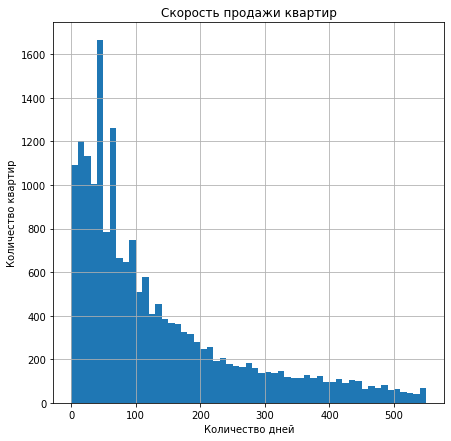

In [127]:
# делаем срез данных до значения в 1300 дней
days_exposition_slice = data_filtered.query('days_exposition <= 1300')

# строим гистограмму по столбцу days_exposition
days_exposition_slice['days_exposition'].hist(bins=55, range = (0, 1350), figsize=(7, 7))
plt.title('Скорость продажи квартир')
plt.xlabel('Количество дней')
plt.ylabel('Количество квартир')
plt.show()

# строим гистограмму по столбцу days_exposition
days_exposition_slice['days_exposition'].hist(bins=55, range = (0, 550), figsize=(7, 7))
plt.title('Скорость продажи квартир')
plt.xlabel('Количество дней')
plt.ylabel('Количество квартир')
plt.show()

***Вывод:***\
Чаще всего продажа квартир занимает от 40 до 50 дней, чуть реже - от 60 до 70 дней и еще чуть реже - от 10 до 20 дней.\
Самые быстрые продажи - это те, которые были совершены в срок до 45 дней.\
Необычайно долгие продажи - это те, которые заняли более 229 дней.

#### Факторы, больше всего влияющие на общую (полную) стоимость объекта

Чтобы определить, какие факторы больше всего влияют на стоимость объекта, посчитаем корреляцию, где можно, и построим графики по следующим параметрам:
1) общая площадь;\
2) жилая площадь;\
3) площадь кухни;\
4) количество комнат;\
5) этаж, на котором расположена квартира (первый, последний, другой);\
6) дата размещения (день недели, месяц, год).

**1) общая площадь**

Коэффициент корреляции равен: 0.77


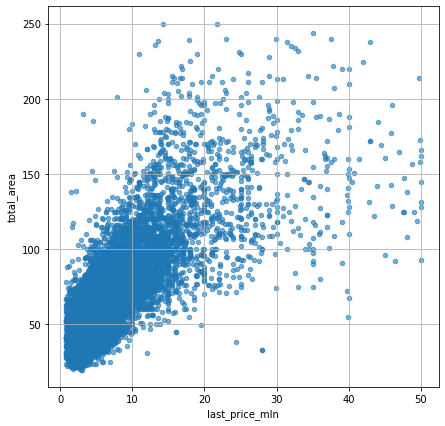

In [128]:
# корреляция между столбцами last_price и total_area

# строим диаграмму рассеивания
data_filtered.plot(x='last_price_mln', y='total_area', kind='scatter', alpha=0.6, figsize=(7,7), grid=True) 
print('Коэффициент корреляции равен:', round(data_filtered['last_price_mln'].corr(data_filtered['total_area']), 2))

***Вывод:***\
Коэффициент корреляции стоимости квартиры и ее общей площади равен 0.77, следовательно при увеличении общей площади, увеличивается и стоимость квартиры. Есть хорошо прослеживающаяся связь.

**2) жилая площадь**

Коэффициент корреляции равен: 0.67


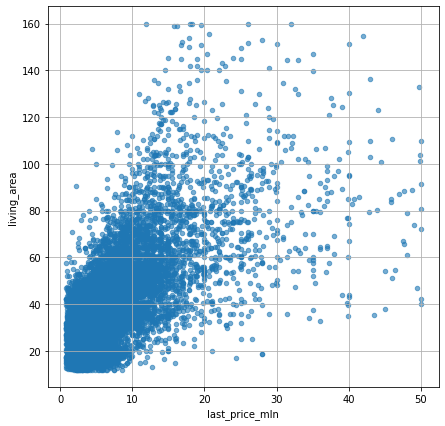

In [129]:
# корреляция между столбцами last_price и living_area

# строим диаграмму рассеивания
data_filtered.plot(x='last_price_mln', y='living_area', kind='scatter', alpha=0.6, figsize=(7,7), grid=True) 
print('Коэффициент корреляции равен:', round(data_filtered['last_price_mln'].corr(data_filtered['living_area']), 2))

 ***Вывод:***\
Коэффициент корреляции стоимости квартиры и ее жилой площади равен 0.67. Заметна хорошая связь.

**3) площадь кухни**

Коэффициент корреляции равен: 0.61


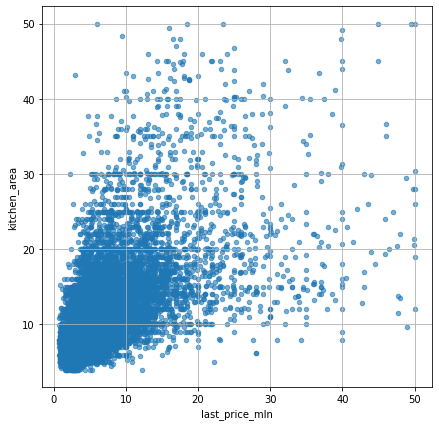

In [130]:
# корреляция между столбцами last_price и kitchen_area

# строим диаграмму рассеивания
data_filtered.plot(x='last_price_mln', y='kitchen_area', kind='scatter', alpha=0.6, figsize=(7,7), grid=True) 
print('Коэффициент корреляции равен:', round(data_filtered['last_price_mln'].corr(data_filtered['kitchen_area']), 2))

***Вывод:***\
Коэффициент корреляции стоимости квартиры и площади кухни равен 0.61. Прослеживается хорошая связь.

**4) количество комнат**

Коэффициент корреляции равен: 0.48


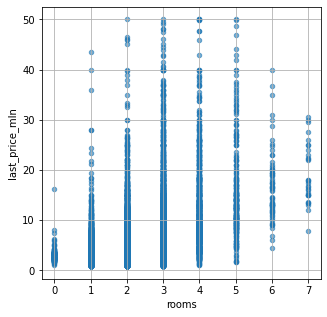

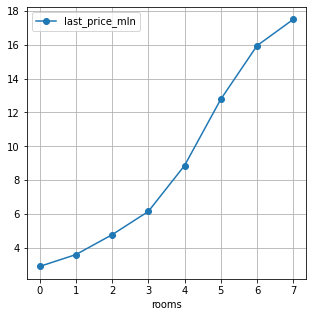

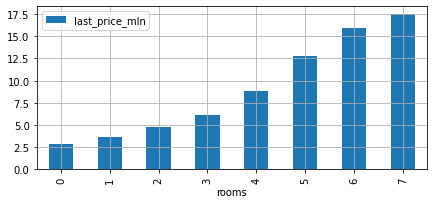

In [131]:
# зависимость между столбцами last_price_mln и rooms

# строим диаграмму рассеивания
data_filtered.plot(x='rooms',y='last_price_mln', kind='scatter', alpha=0.6, figsize=(5,5), grid=True) 
# по ней ничего не понятно, поэтому строим другие графики


# делаем сводную таблицу - группируем по количеству комнат и считаем медиану по каждому значению
data_rooms = data_filtered.pivot_table(index='rooms', values='last_price_mln', aggfunc='median')
#print(data_rooms)

# строим обычный график
data_rooms.plot(y='last_price_mln', style='o-', figsize=(5,5), grid=True)

# строим столбчатый график, он более наглядный
data_rooms = data_rooms.sort_values(by='last_price_mln')
data_rooms.plot(y='last_price_mln', kind='bar', figsize=(7, 3), grid=True)

print('Коэффициент корреляции равен:', round(data_filtered['last_price_mln'].corr(data_filtered['rooms']), 2))


***Вывод:***\
Коэффициент корреляции стоимости квартиры и количества комнат равен 0.48. Связь есть, но слабая.\
Самая высокая стоимость у квартир с 7 комнатами, меньше стоят квартиры с 6 комнатами.\
Видна тенденция повышения стоимости квартиры с увеличением количества комнат.

**5) тип этажа**

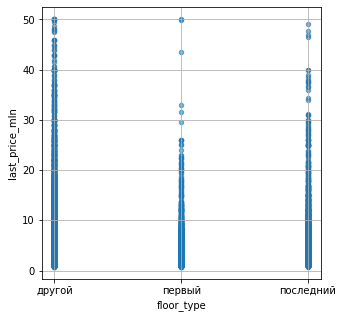

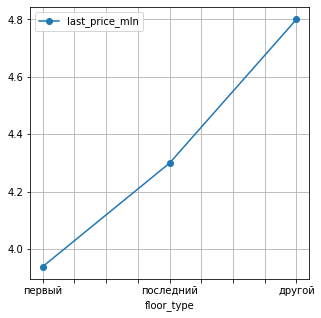

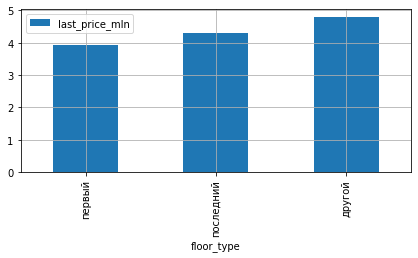

In [132]:
# зависимость между столбцами last_price_mln и floor_type

# строим диаграмму рассеивания
data_filtered.plot(x='floor_type',y='last_price_mln', kind='scatter', alpha=0.6, figsize=(5,5), grid=True) 
# по ней мало что понятно, поэтому строим другие графики

# делаем свобдную таблицу - группируем по количеству комнат и считаем медиану по каждому значению
data_floor_type = data_filtered.pivot_table(index='floor_type', values='last_price_mln', aggfunc='median')

data_floor_type = data_floor_type.sort_values(by='last_price_mln')

# строим обычный график
data_floor_type.plot(y='last_price_mln', style='o-', figsize=(5,5), grid=True)

# строим столбчатый график, он более наглядный
data_floor_type.plot(y='last_price_mln', kind='bar', figsize=(7, 3), grid=True);

***Вывод:***\
Самая высокая стоимость у квартир, расположенных на "другом" этаже, самая низкая - у квартир на первом этаже.


**6) день недели**

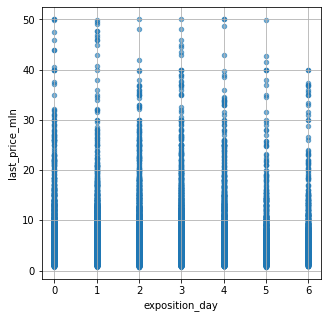

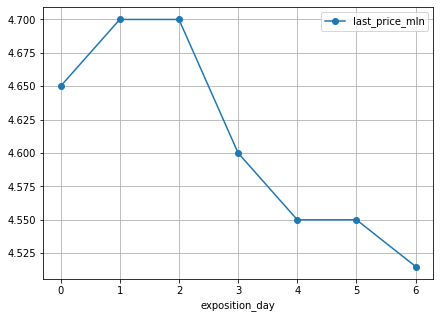

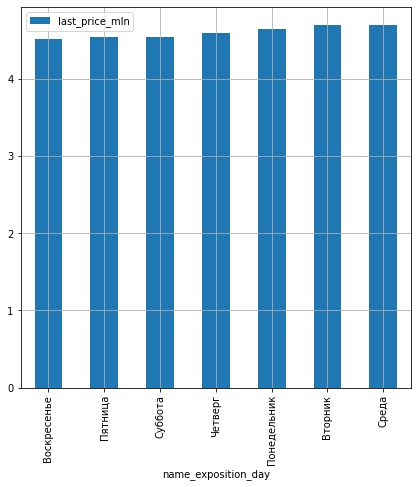

In [133]:
# зависимость между столбцами last_price и data_name_exposition_day

# строим диаграмму рассеивания
data_filtered.plot(x='exposition_day',y='last_price_mln', kind='scatter', alpha=0.6, figsize=(5,5), grid=True) 
# по ней мало что понятно, поэтому строим другие графики

# делаем свобдную таблицу - группируем данные столбца exposition_day 
# по количеству комнат и считаем медиану по каждому значению
data_exposition_day = data_filtered.pivot_table(index='exposition_day', values='last_price_mln', aggfunc='median')

# строим обычный график
data_exposition_day.plot(y='last_price_mln', style='o-', figsize=(7,5), grid=True)

# делаем свобдную таблицу - группируем данные exposition_day по количеству
# комнат и считаем медиану по каждому значению (так будут видны названия дней недели)
data_name_exposition_day = data_filtered.pivot_table(index='name_exposition_day', values='last_price_mln', aggfunc='median')
data_name_exposition_day = data_name_exposition_day.sort_values(by='last_price_mln')

# строим столбчатый график
data_name_exposition_day.plot(y='last_price_mln', kind='bar', figsize=(7, 7), grid=True);

***Вывод:***\
Стоимость квартир увеличивается с воскресенья до вторника, где находится плато максимума до среды, и уменьшается со среды по пятницу (пятница и суббота - плато), а в воскресенье пик минимума цен.


**7) месяц**

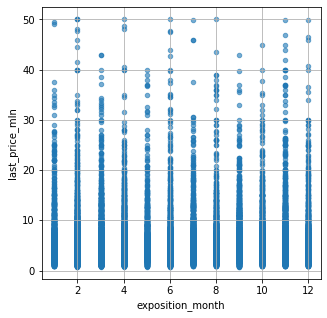

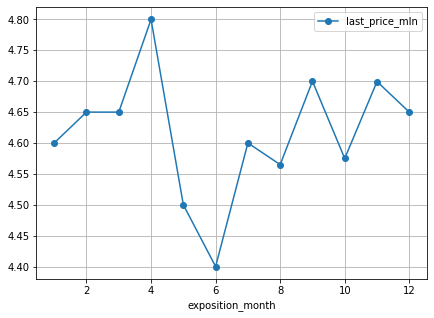

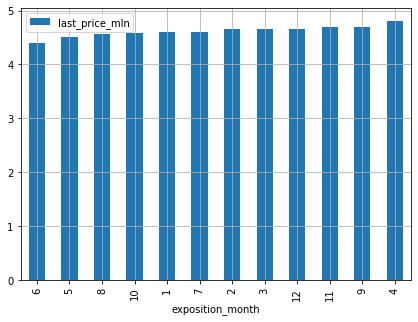

In [134]:
# зависимость между столбцами last_price_mln и exposition_month 

# строим диаграмму рассеивания
data_filtered.plot(x='exposition_month',y='last_price_mln', kind='scatter', alpha=0.6, figsize=(5,5), grid=True) 
# по ней мало что понятно, поэтому строим другие графики

# делаем свобдную таблицу - группируем по количеству комнат и считаем
# медиану по каждому значению
data_exposition_month = data_filtered.pivot_table(index='exposition_month', values='last_price_mln', aggfunc='median')

# строим обычный график
data_exposition_month.plot(y='last_price_mln', style='o-', figsize=(7,5), grid=True)

# строим столбчатый график, он более наглядный
data_exposition_month = data_exposition_month.sort_values(by='last_price_mln')
data_exposition_month.plot(y='last_price_mln', kind='bar', figsize=(7, 5), grid=True);

***Вывод:***\
График неровный, видны резкие изменения стоимости квартир в зависимости от месяца: 6 (июнь) - пик минимальных цен; 4 (апрель) - пик максимальных цен.\
График неровный, цены меняются каждый месяц, то на подъем, то на спад.

**8) год**

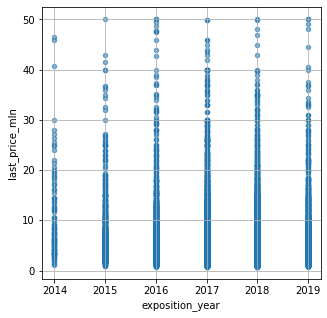

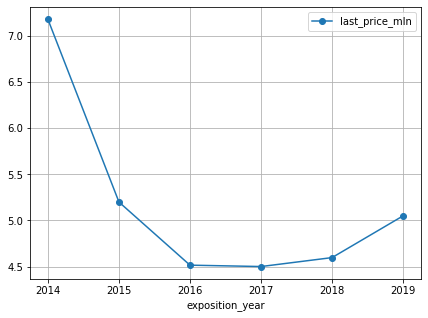

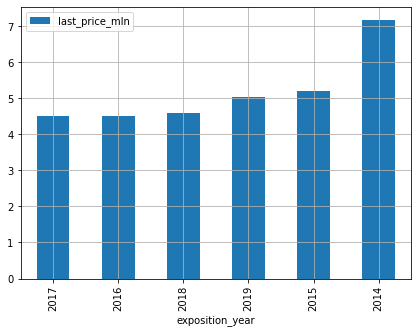

In [135]:
# зависимость между столбцами last_price_mln и exposition_year 

# строим диаграмму рассеивания
data_filtered.plot(x='exposition_year',y='last_price_mln', kind='scatter', alpha=0.6, figsize=(5,5), grid=True) 
# по ней мало что понятно, поэтому строим другие графики

# делаем свобдную таблицу - группируем по количеству комнат и считаем
# медиану по каждому значению
data_exposition_year = data_filtered.pivot_table(index='exposition_year', values='last_price_mln', aggfunc='median')

# строим обычный график
data_exposition_year.plot(y='last_price_mln', style='o-', figsize=(7,5), grid=True)

# строим столбчатый график, он более наглядный
data_exposition_year = data_exposition_year.sort_values(by='last_price_mln')
data_exposition_year.plot(y='last_price_mln', kind='bar', figsize=(7, 5), grid=True);

***Вывод:***\
Средняя стоимость квартир падала, начиная с 2014 года до 2017, где наблюдался минимум за период с 2014 по 2019 года.\
В 2018 стоимость стала расти и примерно сравнялась со стоимостью в 2016 году, рост наблюдается с 2017 по 2019 год.\
При этом самая высокая цена на квартиры была в 2014 году.

In [136]:
# смотрим изменение средней общей площади по годам
data_year_area = data_filtered.pivot_table(index='exposition_year', values='total_area', aggfunc='median')

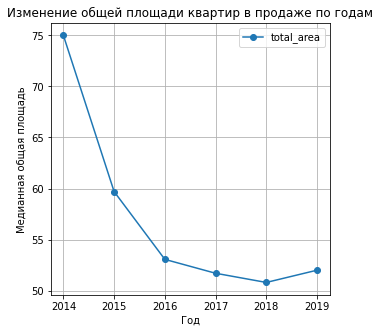

In [137]:
# строим график
data_year_area.plot(y='total_area', style='o-', figsize=(5,5), grid=True)
plt.title('Изменение общей площади квартир в продаже по годам')
plt.xlabel('Год')
plt.ylabel('Медианная общая площадь')
plt.show()

In [138]:
# смотрим изменение средней общей площади по годам
data_year_count = data_filtered.pivot_table(index='exposition_year', values='total_area', aggfunc='count')

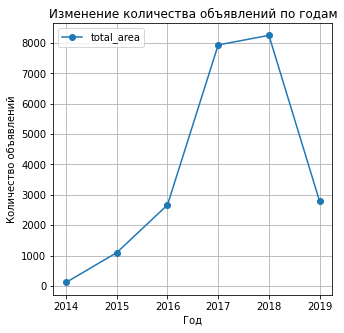

In [139]:
# строим график
data_year_count.plot(y='total_area', style='o-', figsize=(5,5), grid=True)
plt.title('Изменение количества объявлений по годам')
plt.xlabel('Год')
plt.ylabel('Количество объявлений')
plt.show()

Судя по вышепредставленным графикам, снижение стоимости квартир с 2014 года по 2018 и небольшой рост цен в 2019 году можно объяснить резким ростом количества объявлений о продаже квартир с 2014 по 2018 гг, в то время как общая площадь этих квартир падала с того же 2014 года, лишь в 2019 объявлений стало намного меньше, а площадь квартир немного увеличилась.\
То есть большое количество объявлений, которым соответствовали квартиры с меньшей площадью, и вызвало в среднем снижение стоимости квартир с 2014 по 2018 года.

***Факторы, больше всего влияющие на общую (полную) стоимость объекта (Исправленный вариант)***
1. Общая площадь влияет на стоимость квартиры сильнее(коэф.кор-ии 0.77), чем отдельно жилая площадь (0.67) или площадь кухни(0.61), при этом площадь кухни и жилая площадь влияют на стоимость примерно в равной степени.
2. Заметен рост стоимости квартир в зависимости от увеличения количества комнат.
3. Видна связь между типом этажа и стоимостью квартиры: квартиры, расположенные на "другом" этаже, имеют самую высокую стоимость, а квартиры на первом этаже самые дешевые.
4. Прослеживается зависимость стоимости квартир от дня недели размещения объявления: она увеличивается с воскресенья до вторника, где находится плато максимума до среды, и уменьшается со среды по пятницу (пятница и суббота - плато), а в воскресенье пик минимума цен.
5. Нет корреляции между порядком месяцев в году, в которые было размещено объявление, и изменением стоимости квартир, график неравномерный, при этом июнь - пик минимальных цен; апрель - пик максимальных цен.
6. Видна некоторая зависимость между годом размещения объявления и стоимостью квартиры: с 2014 по 2017 год стоимость падала, после чего начала расти к 2019-му, это связано с резким увеличением количества объявлений с 2014 по 2018 гг, в то время как общая площадь квартир уменьшалась с того же 2014 года; при этом в 2019 году ситуация немного изменилась: объявлений стало намного меньше, а общая площадь продаваемых квартир увеличилась.

#### Средняя стоимость одного квадратного метра в 10 пунктах

                   count       price
locality_name                       
Санкт-Петербург    15199  104328.360
поселок Мурино       514   85145.665
поселок Шушары       430   76573.505
Всеволожск           394   65789.470
Пушкин               358   99725.495
Колпино              337   74722.220
Гатчина              307   67796.610
поселок Парголово    296   90938.870
деревня Кудрово      295   92000.000
Выборг               232   58133.215


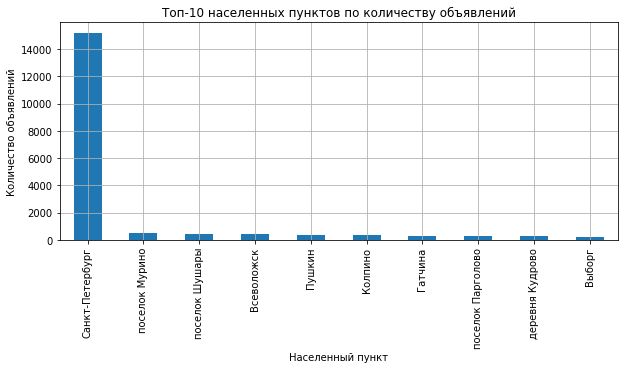

In [140]:
# считаем медианную стоимость одного квадратного метра, группируя 
# их по населенным пунктам
data_price_one_sqr_meter = data_filtered.pivot_table(index='locality_name',\
                                                     values='price_one_sqr_meter', \
                                                     aggfunc=['count', 'median'])
# переименовываем двухэтажные названия стобцов
data_price_one_sqr_meter.columns = ['count', 'price']

# сортируем по убыванию количества объявлений
data_price_one_sqr_meter = data_price_one_sqr_meter.sort_values(by='count', ascending=False)

# создаем переменную, в которую сохраняем топ-10 населенных пунктов с самым большим количеством объявлений
schedule_top10_1 = data_price_one_sqr_meter.head(10)
print(schedule_top10_1)

schedule_top10_1['count'].plot(kind='bar', figsize = (10,4), grid=True)
plt.xlabel('Населенный пункт')
plt.ylabel('Количество объявлений')
plt.title('Топ-10 населенных пунктов по количеству объявлений')
plt.show()


                   count       price
locality_name                       
Санкт-Петербург    15199  104328.360
Пушкин               358   99725.495
деревня Кудрово      295   92000.000
поселок Парголово    296   90938.870
поселок Мурино       514   85145.665
поселок Шушары       430   76573.505
Колпино              337   74722.220
Гатчина              307   67796.610
Всеволожск           394   65789.470
Выборг               232   58133.215


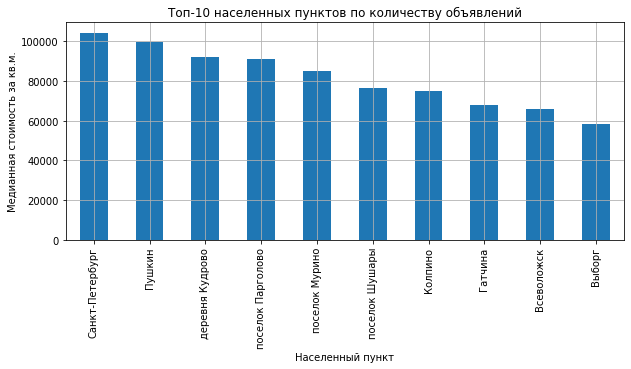

In [141]:
# сохраняем первые 10 строк из него в новый датафрейм
data_price_one_sqr_meter_2 = data_price_one_sqr_meter.head(10)

# сортируем новый датафрейм по убыванию стоимости одного квадратного метра и сохраняем в отдельную переменную
schedule_top10_2 = data_price_one_sqr_meter_2.sort_values(by='price', ascending=False)
print(schedule_top10_2)

# строим график
schedule_top10_2['price'].plot(kind='bar', figsize = (10,4), grid=True)
plt.xlabel('Населенный пункт')
plt.ylabel('Медианная стоимость за кв.м.')
plt.title('Топ-10 населенных пунктов по количеству объявлений')
plt.show()


***Вывод по 10 пунктам с наибольшим количеством объявлений:***\
Больше всего объявлений было дано по городу Санкт-Петербург(15199), далее в порядке убывания: поселок Мурино, поселок Шушары, Всеволожск, Пушкин, Колпино, Гатчина, поселок Парголово, деревня Кудрово, Выборг.\
Из этих 10 пунктов самая высокая стоимость одного квадратного метра в Санкт-Петербурге(104328.360 руб), а самая низкая в Выборге(58133.215 руб).

#### Средняя стоимость квартир в Санкт-Петербурге

In [143]:
# создаем отдельный датафрем с информацией только про объекты в Санкт-Петербурге
data_spb = data_filtered.query('locality_name == "Санкт-Петербург"')

# создаем сводную таблицу, где группируем среднюю стоимость квартир
# по расстоянию в километрах от центра города
data_spb_km = data_spb.pivot_table(index='distance_city_center_km', values='last_price_mln', aggfunc='mean')
print(data_spb_km.sort_values(by='last_price_mln', ascending=False))


                         last_price_mln
distance_city_center_km                
0.0                           20.152793
1.0                           12.706503
2.0                           11.860767
6.0                           11.486618
5.0                           11.476694
7.0                           11.408383
4.0                           10.936140
3.0                           10.112374
8.0                            8.897827
27.0                           8.300000
9.0                            6.924037
10.0                           6.404947
11.0                           6.090714
13.0                           6.070203
20.0                           5.845994
12.0                           5.798130
15.0                           5.790966
14.0                           5.589802
21.0                           5.489381
22.0                           5.415524
16.0                           5.384142
17.0                           5.216262
19.0                           5.054145


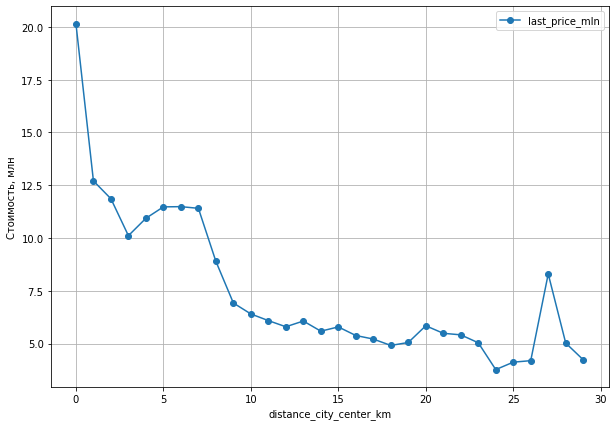

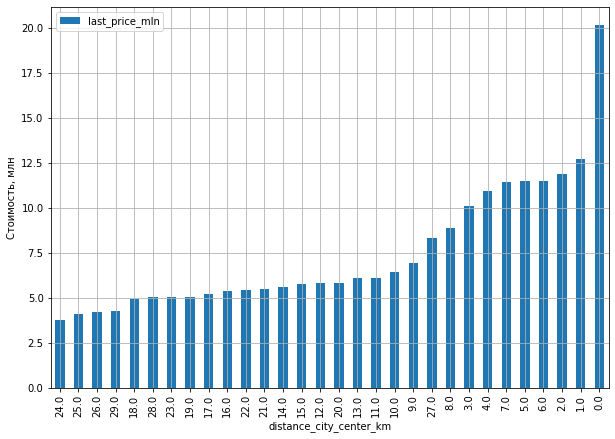

In [144]:
# строим обычный график
data_spb_km.plot(y='last_price_mln', style='o-', figsize=(10,7), grid=True)
plt.ylabel('Стоимость, млн')


# строим столбчатый график
data_spb_km = data_spb_km.sort_values(by='last_price_mln')
data_spb_km.plot(y='last_price_mln', kind='bar', figsize=(10, 7), grid=True)
plt.ylabel('Стоимость, млн');

***Вывод:***\
Стоимость квартир уменьшается с каждым километром дальше от центра Санкт-Петербурга.\
Максимальная средняя стоимость (20.1 млн) наблюдается у квартир на расстоянии менее 1 км до центра, минимальная на расстоянии в 24 км (3.7 млн). 


In [145]:
# изучаем записи которые привели к выбросу на 27-м км
print(data_filtered.query('locality_name == "Санкт-Петербург" and distance_city_center_km == 27'))

      total_images  last_price  total_area first_day_exposition  rooms  \
748             13  14350000.0        74.0           2017-11-28      2   
5961             6   2250000.0        32.0           2018-02-27      1   

      ceiling_height  floors_total  living_area  floor  is_apartment  ...  \
748             3.13             5         30.0      3         False  ...   
5961             NaN             2         16.5      2         False  ...   

      ponds_nearest  days_exposition  price_one_sqr_meter  exposition_day  \
748             NaN            128.0            193918.92               1   
5961            NaN            178.0             70312.50               1   

     name_exposition_day  exposition_month  exposition_year  floor_type  \
748              Вторник                11             2017      другой   
5961             Вторник                 2             2018   последний   

      distance_city_center_km  last_price_mln  
748                      27.0          

*Видно, что к выбросу на 27 км привела запись о квартире стоимостью 14.35 млн рублей и общей площадью 74 метра квадратных.\
На этапе изучения данных по параметрам был установлен порог выбивающихся значений в 50 млн рублей, следовательно запись про эту квартиру не считается выбросом, а стоимость скорее всего объясняется факторами, которые не отражены в датафрейме.*

*После обработки аномалий, пик на 5-ом км не виден, но остался провал на 3-ем.\
Посмотрим, в чем дело, ниже.*

In [146]:
# отбираем данные для 3-го километра и для сравнения на 2-ом и 4-ом
data_3_km = data_filtered[data_filtered['distance_city_center_km'] == 3]
data_2_km = data_filtered[data_filtered['distance_city_center_km'] == 2]
data_4_km = data_filtered[data_filtered['distance_city_center_km'] == 4]


# группируем данные по категориям и километрам, считаем количество квартир и вычисляем долю каждой категории
data_3_km_stats = data_3_km.groupby(['floor_type'])['floor_type'].count() / len(data_3_km)
data_2_km_stats = data_2_km.groupby(['floor_type'])['floor_type'].count() / len(data_2_km)
data_4_km_stats = data_4_km.groupby(['floor_type'])['floor_type'].count() / len(data_4_km)

print("Доля категорий квартир на 3-м километре:")
print(data_3_km_stats)
print()
print("Доля категорий квартир на 2-м километре:")
print(data_2_km_stats)
print()
print("Доля категорий квартир на 4-м километре:")
print(data_4_km_stats)


Доля категорий квартир на 3-м километре:
floor_type
другой       0.606061
первый       0.160606
последний    0.233333
Name: floor_type, dtype: float64

Доля категорий квартир на 2-м километре:
floor_type
другой       0.581818
первый       0.160000
последний    0.258182
Name: floor_type, dtype: float64

Доля категорий квартир на 4-м километре:
floor_type
другой       0.719755
первый       0.116386
последний    0.163859
Name: floor_type, dtype: float64


Прослеживается общая закономерность для стоимости квартир в центре города: доли последних и первых этажей на 2, 3 и 4 километрах намного меньше доли других этажей.\
Квартир на первом этаже может быть меньше в центре города из-за повышенного уровня шума, а также магазинов, ресторанов, а квартиры на последних этажах могут быть ограничены из-за наличия крышных конструкций, ограничивающих вид и доступ к крыше.

Объяснение резкого спада и роста стоимости ниже.

In [147]:
# check
data_5_km = data_filtered[data_filtered['distance_city_center_km'] == 5]
data_5_km_stats = (data_5_km.groupby(['floor_type'])['floor_type'].count() / len(data_5_km)).to_frame()
data_3_km_stats = data_3_km_stats.to_frame()

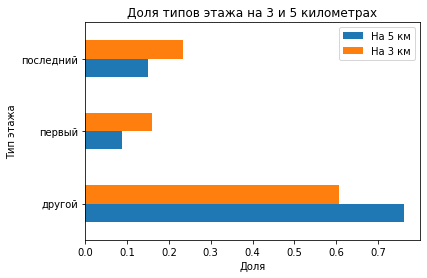

In [148]:
# check
pd.merge(data_5_km_stats, data_3_km_stats, left_index=True, right_index=True).plot.barh();
plt.xlabel('Доля') # добавила легенду и оформила график
plt.ylabel('Тип этажа')
plt.title('Доля типов этажа на 3 и 5 километрах')
plt.legend(['На 5 км', 'На 3 км'])
plt.show()

**Добавила вывод:**\
доля квартир с более дешевым типом этажа (первый, последний) намного больше на 3-м километре, чем на 5-ом, что объясняет провал стоимости квартир на 3 километре и резкий скачок к 5-му.

**Общий вывод по исследованию "Средняя стоимость квартир в Санкт-Петербурге":**
* стоимость квартир уменьшается с каждым километром дальше от центра Санкт-Петербурга;
* максимальная средняя стоимость (20.1 млн) наблюдается у квартир на расстоянии менее 1 км до центра, минимальная на расстоянии в 24 км (3.7 млн);
* был обнаружен резкий пик на 27 км, но по причине очень малого количества записей из-за нерепрезентативности это наблюдение отвергаем;
* доля квартир с более дешевым типом этажа (первый, последний) намного больше на 3-м километре, чем на 5-ом, что объясняет провал стоимости квартир на 3 километре и резкий скачок к 5-му.


### Напишите общий вывод

**Исследование проводилось на основе** данных сервиса Яндекс Недвижимость — архиве объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет.
По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных.\
\
\
**Задача была следующая:** нужно было научиться определять рыночную стоимость объектов недвижимости, для чего нужно было провести исследовательский анализ данных и установить параметры, влияющие на цену объектов. 
Результаты исследования помогут построить автоматизированную систему: она отследит аномалии и мошенническую деятельность. 
\
\
\
**На этапе предобработки было сделано:**
1) переименование столбцов по правилам;\
2) обработка пропусков;\
3) проверка и изменение типов данных, чтобы можно было провести анализ с технической стороны;\
4) обработка дубликатов;\
5) добавление новых столбцов, необходимых для дальнейшего анализа (день недели, месяц и год размещения объявления, тип этажа квартиры и расстояние до центра города в километрах).
\
\
\
**Исследовательский анализ данных**

*Было выявлено, что основная доля квартир по объявлениям имели следующие параметры:*
1) общая площадь примерно от 42 до 45 м²;\
2) жилая площадь примерно от 15 до 20 м²;\
3) площадь кухни примерно 8-9 м²;\
4) стоимость 3-4 млн руб;\
5) 2 комнаты, чуть реже 1;\
6) высота потолков примерно 2.5-2.55 м;\
7) тип этажа ни первый, ни последний;\
8) 5 этажей в доме;\
9) расстояние до центра города 11000-16000 м (11-16 км);\
10) расстояние до ближайшего парка 400-500 м.\
\
\
*Скорость продажи квартир:*
* чаще всего от 40 до 50 дней, чуть реже - от 60 до 70 дней;
* самые быстрые продажи - это те, которые были совершены  срок до 45 дней;
* необычайно долгие продажи - это те, которые заняли более 229 дней.

\
*Факторы, больше всего влияющие на общую (полную) стоимость объекта:*

1) общая площадь, при этом чуть меьнше, но примерно равнозначно жилая площадь и площадь кухни;\
2) количество комнат (прямо пропорционально);\
3) тип этажа: квартиры, расположенные вне первого или последнего этажей, имеют самую высокую стоимость, а квартиры на первом этаже самые дешевые;\
4) день недели размещения объявления: стоимость квартир увеличивается с воскресенья до вторника, где находится плато максимума до среды, и уменьшается со среды по пятницу (пятница и суббота - плато), а в воскресенье пик минимума;\
5) год: с 2014 по 2017 год стоимость падала, после чего начала расти к 2019-му, что связано с резким увеличением количества объявлений с 2014 по 2018 гг, в то время как общая площадь квартир уменьшалась с того же 2014 года; при этом в 2019 году ситуация немного изменилась: объявлений стало намного меньше, а общая площадь продаваемых квартир увеличилась..\
но:\
не удалось проследить зависимость между:
* порядком месяцев в году, в которые было размещено объявление, и изменением стоимости квартир, так как график неравномерный;

\
*Стоимость одного квадратного метра*\
Из 10 пунктов с наибольшим количеством объявлений самая высокая стоимость одного квадратного метра в Санкт-Петербурге (104328.360 руб), а самая низкая в Выборге (58133.215 руб).

\
*Стоимость квартир в Санкт-Петербурге на разном удалении от центра города*\
Стоимость квартир уменьшается с каждым километром дальше от центра Санкт-Петербурга.
Максимальная средняя стоимость (20.1 млн) наблюдается у квартир на расстоянии менее 1 км до центра, минимальная на расстоянии в 24 км (3.7 млн).\
В ходе исследования был обнаружен резкий пик на 27 км, но из-за нерепрезентативности записей это наблюдение отвергаем; а также было обнаружено, что доля квартир с более дешевым типом этажа (первый, последний) намного больше доли квартир с более ценным типом этажа на 3-м километре, чем на 5-ом, что объясняет провал стоимости квартир на 3 километре и резкий скачок к 5-му.

\
**Возможные рекомендации:**
1. Проверить корректность работы геосервисов, которые предоставили часть данных, так как большое количество пропусков в столбцах "расстояние до центра города", "расстояние до аэропорта", "расстояние до ближайшего парка", "расстояние до ближайшего пруда", "количество парков в радиусе 3000 м", "количество прудов в радиусе 3000м" и "название населенного пункта" может негативно сказываться на объективности исследования из-за неполноты данных.
2. Провести исследование и анализ по более актуальным данным, так как в данном исследовании указан временной период 2014-2019гг и выводы могут не отражать объективную оценку ситуации в настоящем времени.
3. Для более глубокого анализа можно провести исследование по другим факторам, которые тоже влияют на стоимость квартир, например, инфраструктура района, где находится квартира, или общее благосостояние граждан.